# 23CSE301 Machine Learning — Capstone Project
## Classification Track, Part A

**Dataset:** Comprehensive Diabetes Clinical Dataset — 100,000 records, 16 columns
**Target:** `diabetes` — binary, 0 = non-diabetic, 1 = diabetic
**Task:** supervised binary classification

### Problem statement

Predict whether a patient has diabetes from routinely collected clinical and
demographic measurements: age, BMI, HbA1c, blood glucose, smoking history,
hypertension and heart disease.

### Reproducibility

`random_state = 42` is used everywhere a seed is accepted. Every transformer
that learns a parameter is fitted on the training split only.

---
# 1. Data Loading and Audit

## 1.1 Imports and configuration

One configuration cell fixes the seed, the plotting style and a colourblind-safe
palette so every figure later in the notebook is consistent.

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# one seed for the whole notebook, so every run reproduces exactly
RANDOM_STATE = 42
TEST_SIZE = 0.20
PALETTE = "colorblind"

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
})

# reused whenever a plot is coloured by class
CLASS_COLOURS = {0: sns.color_palette(PALETTE)[0], 1: sns.color_palette(PALETTE)[3]}
CLASS_LABELS = {0: "Non-diabetic (0)", 1: "Diabetic (1)"}

print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)
print("seaborn     ", sns.__version__)
print("\nRANDOM_STATE =", RANDOM_STATE)

pandas       3.0.6
numpy        2.5.3
scikit-learn 1.9.1
seaborn      0.13.2

RANDOM_STATE = 42


## 1.2 Load the dataset

The loader resolves any `*.csv` in `../data/` rather than hard-coding a filename,
and fails with a clear message if the file is missing.

In [2]:
DATA_DIR = os.path.join("..", "data")

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
if not csv_files:
    raise FileNotFoundError(
        f"No CSV found in {os.path.abspath(DATA_DIR)}. "
        "See data/README.md for the dataset description."
    )

DATA_PATH = csv_files[0]
df_raw = pd.read_csv(DATA_PATH)

print("File :", os.path.abspath(DATA_PATH))
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

File : /Users/renexaan/Documents/glucotrack/data/diabetes_dataset.csv
Shape: 100,000 rows x 16 columns


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


## 1.3 Structural audit

A single consolidated table is easier to read than separate `dtypes`, `isna()` and
`nunique()` calls. It reports, per column: the dtype, how many values are missing,
how many distinct values there are, and a sample of those values.

In [3]:
audit = pd.DataFrame({
    "dtype":     df_raw.dtypes.astype(str),
    "non_null":  df_raw.notna().sum(),
    "missing":   df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean() * 100).round(3),
    "n_unique":  df_raw.nunique(),
})
# a few example values make it obvious which columns are categorical vs continuous
audit["example_values"] = [
    ", ".join(map(str, df_raw[c].dropna().unique()[:4]))[:55] for c in df_raw.columns
]

print("Total missing values :", int(df_raw.isna().sum().sum()))
print("Duplicate rows       :", int(df_raw.duplicated().sum()))
audit

Total missing values : 0
Duplicate rows       : 14


,dtype,non_null,missing,missing_%,n_unique,example_values
year,int64,100000,0,0.0,7,"2020, 2015, 2016, 2019"
gender,str,100000,0,0.0,3,"Female, Male, Other"
age,float64,100000,0,0.0,102,"32.0, 29.0, 18.0, 41.0"
location,str,100000,0,0.0,55,"Alabama, Alaska, Arizona, Arkansas"
race:AfricanAmerican,int64,100000,0,0.0,2,"0, 1"
race:Asian,int64,100000,0,0.0,2,"0, 1"
race:Caucasian,int64,100000,0,0.0,2,"0, 1"
race:Hispanic,int64,100000,0,0.0,2,"0, 1"
race:Other,int64,100000,0,0.0,2,"1, 0"
hypertension,int64,100000,0,0.0,2,"0, 1"


In [4]:
# distribution of the numeric columns: range, centre and spread
df_raw.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
year,100000.0,2018.361,1.345,2015.00,2019.00,2019.00,2019.00,2022.00
age,100000.0,41.886,22.517,0.08,24.00,43.00,60.00,80.00
race:AfricanAmerican,100000.0,0.202,0.402,0.00,0.00,0.00,0.00,1.00
race:Asian,100000.0,0.200,0.400,0.00,0.00,0.00,0.00,1.00
race:Caucasian,100000.0,0.199,0.399,0.00,0.00,0.00,0.00,1.00
race:Hispanic,100000.0,0.199,0.399,0.00,0.00,0.00,0.00,1.00
race:Other,100000.0,0.200,0.400,0.00,0.00,0.00,0.00,1.00
hypertension,100000.0,0.075,0.263,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039,0.195,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.321,6.637,10.01,23.63,27.32,29.58,95.69


## 1.4 Target variable and class balance

Class balance determines both the metrics that are meaningful and how the
train/test split has to be performed, so it is measured before anything else.

In [5]:
TARGET = "diabetes"

counts = df_raw[TARGET].value_counts().sort_index()
pcts = df_raw[TARGET].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "class":      [CLASS_LABELS[i] for i in counts.index],
    "count":      counts.values,
    "percentage": pcts.round(2).values,
})

imbalance_ratio = counts.max() / counts.min()

print(summary.to_string(index=False))
print(f"\nMajority class  : {pcts.max():.2f}%")
print(f"Minority class  : {pcts.min():.2f}%")
print(f"Imbalance ratio : {imbalance_ratio:.2f} : 1")
print(f"\nA model predicting the majority class for every row would score "
      f"{pcts.max():.1f}% accuracy while identifying no diabetic patients.")

           class  count  percentage
Non-diabetic (0)  91500        91.5
    Diabetic (1)   8500         8.5

Majority class  : 91.50%
Minority class  : 8.50%
Imbalance ratio : 10.76 : 1

A model predicting the majority class for every row would score 91.5% accuracy while identifying no diabetic patients.


### Observation — 1

- 100,000 rows, 16 columns, and no missing values anywhere in the frame.
- 14 exact duplicate rows are present.
- Class split is 91,500 non-diabetic to 8,500 diabetic, a ratio of 10.76 to 1.
- `race` arrives already one-hot encoded across five indicator columns rather than as a single categorical column.
- `smoking_history` includes a "No Info" level, which records missingness rather than a behaviour.
- `hbA1c_level` and `blood_glucose_level` each take only 18 distinct values, and `bmi` has one value repeated far more than any other.

---
# 2. Exploratory Data Analysis

All EDA runs on the raw, unsplit frame. That is legitimate because it is purely
descriptive: nothing measured here is fed into a fitted transformer. Every
transformer that learns a parameter is fitted on the training split alone in
section 3.

## 2.1 Distribution of each numeric feature

Continuous features: ['year', 'age', 'bmi', 'hbA1c_level', 'blood_glucose_level']
Binary flags excluded: ['diabetes', 'hypertension', 'heart_disease', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other']


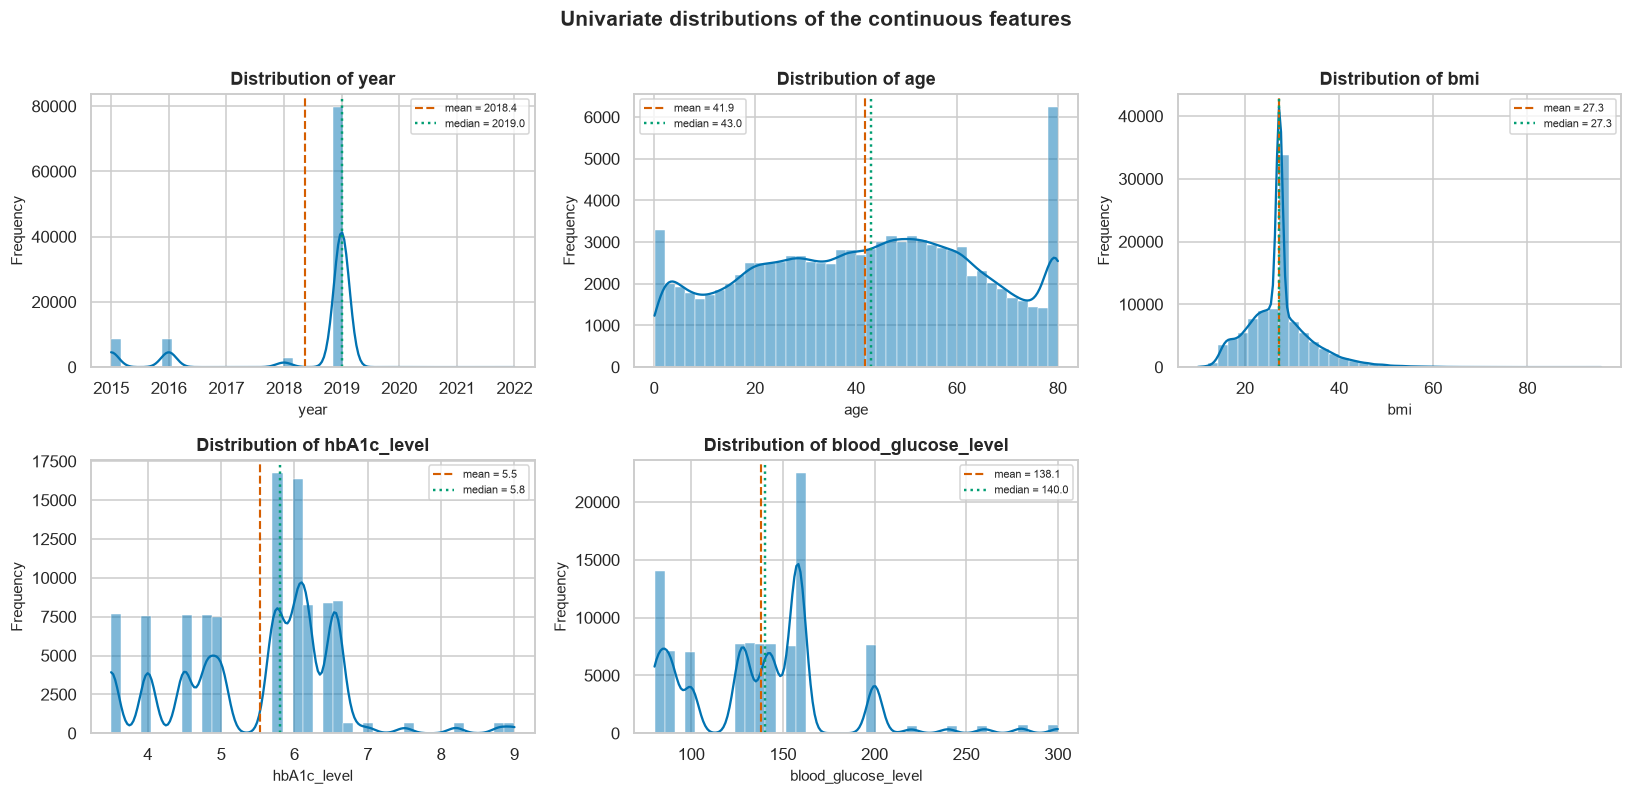

,skew,kurtosis,min,max,n_unique
year,-1.752,1.291,2015.00,2022.00,7
age,-0.052,-1.004,0.08,80.00,102
bmi,1.044,3.521,10.01,95.69,4247
hbA1c_level,-0.067,0.215,3.50,9.00,18
blood_glucose_level,0.822,1.738,80.00,300.00,18


In [6]:
numeric_cols_raw = df_raw.select_dtypes(include=np.number).columns.tolist()

# the target, the comorbidity flags and the race indicators are all 0/1 columns,
# so a histogram of them says nothing useful - exclude them from this grid
race_flag_cols = [c for c in df_raw.columns if c.startswith("race:")]
binary_flags = [TARGET, "hypertension", "heart_disease"] + race_flag_cols
continuous_cols = [c for c in numeric_cols_raw if c not in binary_flags]

print("Continuous features:", continuous_cols)
print("Binary flags excluded:", [c for c in binary_flags if c in numeric_cols_raw])

ncols = 3
nrows = int(np.ceil(len(continuous_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.6 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, continuous_cols):
    sns.histplot(data=df_raw, x=col, bins=40, kde=True, ax=ax,
                 color=sns.color_palette(PALETTE)[0], edgecolor="white", linewidth=0.3)
    ax.axvline(df_raw[col].mean(), color=sns.color_palette(PALETTE)[3],
               linestyle="--", linewidth=1.4, label=f"mean = {df_raw[col].mean():.1f}")
    ax.axvline(df_raw[col].median(), color=sns.color_palette(PALETTE)[2],
               linestyle=":", linewidth=1.6, label=f"median = {df_raw[col].median():.1f}")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=7, frameon=True)

for ax in axes[len(continuous_cols):]:
    ax.set_visible(False)

fig.suptitle("Univariate distributions of the continuous features",
             fontsize=14, fontweight="bold", y=1.002)
plt.tight_layout()
plt.show()

# skew quantifies what the plots show: how far from symmetric each feature is
pd.DataFrame({
    "skew":     df_raw[continuous_cols].skew().round(3),
    "kurtosis": df_raw[continuous_cols].kurtosis().round(3),
    "min":      df_raw[continuous_cols].min().round(2),
    "max":      df_raw[continuous_cols].max().round(2),
    "n_unique": df_raw[continuous_cols].nunique(),
})

### Observation — 2.1

- `bmi` is right-skewed and has one value, 27.32, repeated far more than any other.
- `hbA1c_level` and `blood_glucose_level` each take only 18 distinct values, so their histograms are spiky rather than smooth.
- `age` is broadly flat across the adult range and close to symmetric.
- `year` varies over a small set of values and shows no clear shape.

## 2.2 Correlation heatmap

Pearson correlation across the numeric columns, to see which features move with
the target and whether any predictors duplicate one another.

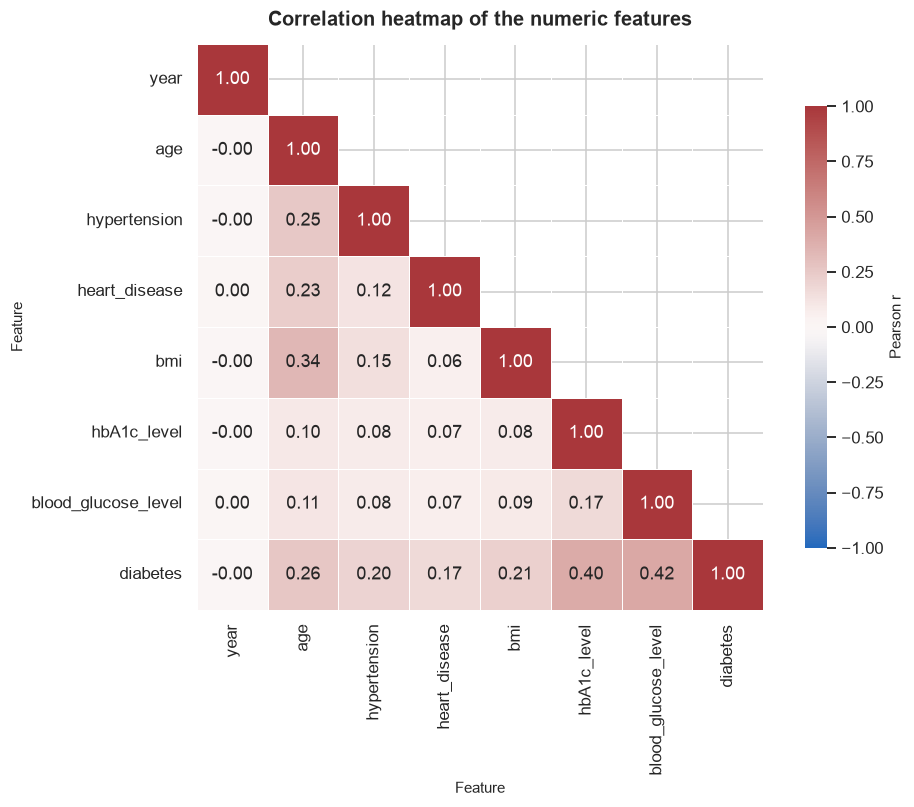

Correlation with the target, ranked by absolute value:


,r
blood_glucose_level,0.4196
hbA1c_level,0.4007
age,0.2580
bmi,0.2144
hypertension,0.1978
heart_disease,0.1717
year,-0.0035


In [7]:
corr_cols = [c for c in numeric_cols_raw if c not in race_flag_cols]
corr = df_raw[corr_cols].corr(numeric_only=True)

# mask the upper triangle so each pair is shown once
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.78, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation heatmap of the numeric features",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Feature")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print("Correlation with the target, ranked by absolute value:")
corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(4).to_frame("r")

### Observation — 2.2

- Correlation with the target: `blood_glucose_level` 0.4196, `hbA1c_level` 0.4007, `age` 0.2580, `bmi` 0.2144, `hypertension` 0.1978, `heart_disease` 0.1717.
- `year` is -0.0035, effectively zero.
- No pair of predictors is strongly correlated with any other predictor; the largest off-diagonal values are small.

## 2.3 Target class distribution

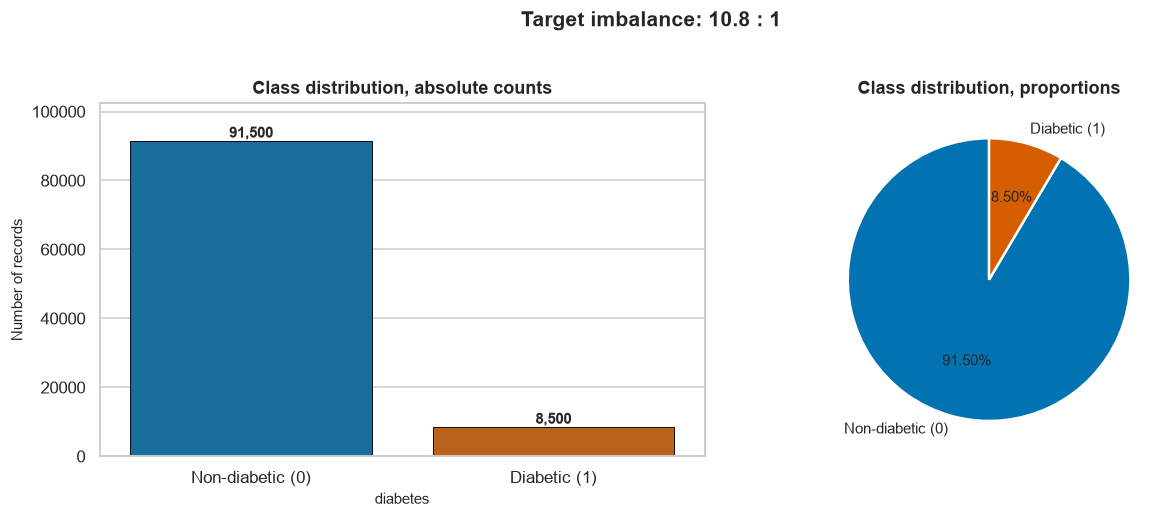

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.countplot(data=df_raw, x=TARGET, order=[0, 1], ax=axes[0],
              hue=TARGET, legend=False,
              palette=[CLASS_COLOURS[0], CLASS_COLOURS[1]],
              edgecolor="black", linewidth=0.6)
axes[0].set_title("Class distribution, absolute counts")
axes[0].set_xlabel("diabetes")
axes[0].set_ylabel("Number of records")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels([CLASS_LABELS[0], CLASS_LABELS[1]])
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, counts.max() * 1.12)

axes[1].pie(counts.values,
            labels=[CLASS_LABELS[i] for i in counts.index],
            colors=[CLASS_COLOURS[0], CLASS_COLOURS[1]],
            autopct="%1.2f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.6},
            textprops={"fontsize": 10})
axes[1].set_title("Class distribution, proportions")
axes[1].set_ylabel("")

fig.suptitle(f"Target imbalance: {imbalance_ratio:.1f} : 1",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Observation — 2.3

- 91.5% of records are non-diabetic and 8.5% are diabetic, a ratio of 10.76 to 1.
- The majority-class baseline accuracy is therefore 91.5%.
- The split in section 3 uses `stratify=y` so both partitions keep the same 8.5% rate.

## 2.4 Feature-target relationships

With 100,000 records a raw scatter is a solid block of ink, so each panel is drawn
from a reproducible 6,000-row sample with alpha blending. The sampling affects the
picture only, never the modelling.

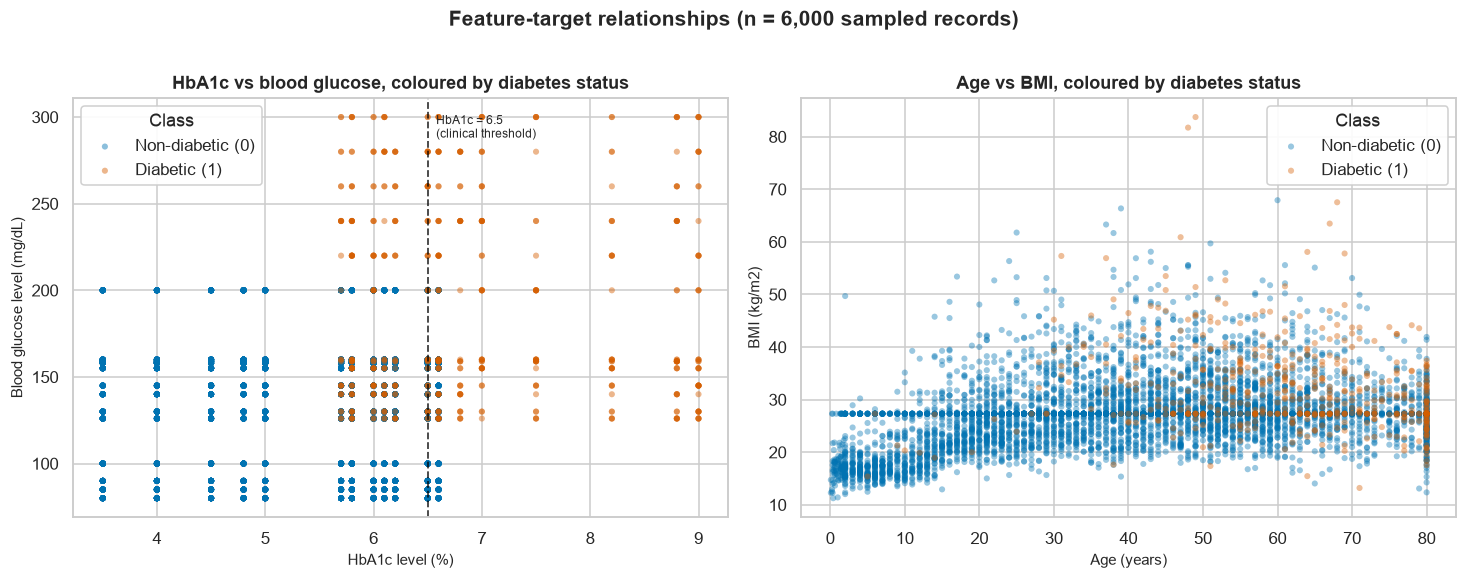

age           bmi        hbA1c_level        blood_glucose_level  \
           mean median   mean median        mean median                mean   
diabetes                                                                      
0         40.12   40.0  26.89  27.32        5.40    5.8              132.85   
1         60.95   62.0  31.99  29.97        6.93    6.6              194.09   

                 
         median  
diabetes         
0         140.0  
1         160.0

In [9]:
SCATTER_N = 6_000
df_s = df_raw.sample(n=min(SCATTER_N, len(df_raw)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

# the two diagnostic markers against each other, coloured by class
for cls in [0, 1]:
    sub = df_s[df_s[TARGET] == cls]
    axes[0].scatter(sub["hbA1c_level"], sub["blood_glucose_level"],
                    s=16, alpha=0.45, color=CLASS_COLOURS[cls],
                    label=CLASS_LABELS[cls], edgecolors="none")
axes[0].axvline(6.5, color="black", linestyle="--", linewidth=1.2, alpha=0.75)
axes[0].text(6.55, axes[0].get_ylim()[1] * 0.97, " HbA1c = 6.5\n (clinical threshold)",
             fontsize=8, va="top")
axes[0].set_title("HbA1c vs blood glucose, coloured by diabetes status")
axes[0].set_xlabel("HbA1c level (%)")
axes[0].set_ylabel("Blood glucose level (mg/dL)")
axes[0].legend(title="Class", loc="upper left", framealpha=0.92)

# the two main risk factors, for contrast
for cls in [0, 1]:
    sub = df_s[df_s[TARGET] == cls]
    axes[1].scatter(sub["age"], sub["bmi"],
                    s=16, alpha=0.40, color=CLASS_COLOURS[cls],
                    label=CLASS_LABELS[cls], edgecolors="none")
axes[1].set_title("Age vs BMI, coloured by diabetes status")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("BMI (kg/m2)")
axes[1].legend(title="Class", loc="upper right", framealpha=0.92)

fig.suptitle(f"Feature-target relationships (n = {len(df_s):,} sampled records)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# the same relationships as numbers
df_raw.groupby(TARGET)[["age", "bmi", "hbA1c_level", "blood_glucose_level"]] \
      .agg(["mean", "median"]).round(2)

### Observation — 2.4

- In the HbA1c against glucose panel, diabetic records sit almost entirely in the upper-right region.
- The boundary between the two classes runs along the axes rather than diagonally.
- In the age against BMI panel the two classes overlap heavily across the whole range.
- Group means: diabetic records average a higher HbA1c and glucose than non-diabetic records, with a smaller gap on BMI and age.

---
# 3. Preprocessing and Feature Engineering

### Order of operations

The sequence below is deliberate, and it is what keeps test data out of the
training pipeline.

| Step | Operation | Applied to | Safe because |
|------|-----------|-----------|--------------|
| 3.1 | Reconstruct `race` | full frame | deterministic reshape, learns nothing |
| 3.2 | Drop duplicates | full frame | row identity only, no statistics |
| 3.3 | Declare missing-value strategy | — | declared now, fitted later |
| 3.4 | Measure IQR outliers | full frame | reporting only, bounds refitted in 3.7 |
| 3.5 | Feature engineering | row-wise | each row uses only its own values |
| 3.6 | Train/test split | — | the split itself |
| 3.7 | Fit imputer, encoder, scaler | **train only** | `.fit()` never sees test data |

Steps 3.1, 3.2 and 3.5 happen before the split because none of them estimates a
parameter from the data. Everything that does - imputation values, category
vocabularies, IQR bounds, means and standard deviations - happens after the
split and is fitted on `X_train` alone.

## 3.1 Reconstruct the `race` column

The dataset ships `race` already one-hot encoded across five columns. Collapsing
it back to a single categorical column lets it be explored and re-encoded under
the same train-only discipline as every other categorical.

In [10]:
df = df_raw.copy()

if race_flag_cols:
    # confirm the indicators really are mutually exclusive before collapsing them
    row_sums = df[race_flag_cols].sum(axis=1)
    print("race indicator row-sums:", row_sums.value_counts().to_dict())
    assert (row_sums == 1).all(), "race indicators are not mutually exclusive"

    df["race"] = df[race_flag_cols].idxmax(axis=1).str.replace("race:", "", regex=False)
    df = df.drop(columns=race_flag_cols)
    print(f"\nCollapsed {len(race_flag_cols)} indicator columns into one 'race' column")
    print("Levels:", sorted(df["race"].unique()))

print("\nShape:", df.shape)
df.head(3)

race indicator row-sums: {1: 100000}

Collapsed 5 indicator columns into one 'race' column
Levels: ['AfricanAmerican', 'Asian', 'Caucasian', 'Hispanic', 'Other']

Shape: (100000, 12)


,year,gender,age,location,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,race
0,2020,Female,32.0,Alabama,0,0,never,27.32,5.0,100,0,Other
1,2015,Female,29.0,Alabama,0,0,never,19.95,5.0,90,0,Asian
2,2015,Male,18.0,Alabama,0,0,never,23.76,4.8,160,0,Other


## 3.2 Duplicate detection and removal

Exact duplicates are removed. In a clinical extract, a record identical across all
16 fields is far more likely to be an export artefact than two genuinely distinct
patients. Leaving them in also lets the same row land in both the training and
test splits, which inflates test scores.

In [11]:
n_before = len(df)
dup_mask = df.duplicated(keep="first")
n_dupes = int(dup_mask.sum())

print(f"Rows before deduplication : {n_before:,}")
print(f"Exact duplicate rows      : {n_dupes:,}  ({n_dupes / n_before * 100:.3f}%)")

if n_dupes:
    print("\nClass balance within the duplicated rows:")
    print(df.loc[dup_mask, TARGET].value_counts().to_string())

df = df.drop_duplicates(keep="first").reset_index(drop=True)

print(f"\nRows after deduplication  : {len(df):,}  (removed {n_before - len(df):,})")
print("Target distribution after :",
      df[TARGET].value_counts(normalize=True).round(4).to_dict())

Rows before deduplication : 100,000
Exact duplicate rows      : 14  (0.014%)

Class balance within the duplicated rows:
diabetes
0    14

Rows after deduplication  : 99,986  (removed 14)
Target distribution after : {0: 0.915, 1: 0.085}


## 3.3 Missing-value strategy

**Strategy: median imputation for numeric features, most-frequent for categorical
features, both fitted on the training split only.**

Median rather than mean for the numeric columns, because section 2.1 showed `bmi`
and `blood_glucose_level` are right-skewed. The mean of a skewed distribution is
pulled toward the tail, so mean-imputation would push every imputed record upward.
The median is not affected by that.

`"No Info"` in `smoking_history` is deliberately left alone rather than imputed. It
records that the information was never collected, not that the patient never
smoked. Replacing it with the modal value would invent a behavioural claim the data
does not support, so it is kept as its own category and the models can use whatever
"not recorded" signals.

This dataset has no true nulls, so the imputers fitted in 3.7 will be no-ops. They
stay in the pipeline so it remains correct if it is ever re-run on an incomplete
extract.

In [12]:
print("Null counts per column:")
print(df.isna().sum().to_string())
print("\nTotal nulls:", int(df.isna().sum().sum()))

if "smoking_history" in df.columns:
    sh = df["smoking_history"].value_counts()
    sh_pct = df["smoking_history"].value_counts(normalize=True) * 100
    print("\n'smoking_history' levels:")
    print(pd.DataFrame({"count": sh, "percent": sh_pct.round(2)}).to_string())
    if "No Info" in sh.index:
        print(f"\n'No Info' covers {sh_pct['No Info']:.2f}% of records, "
              f"kept as its own category rather than imputed.")

Null counts per column:
year                   0
gender                 0
age                    0
location               0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
hbA1c_level            0
blood_glucose_level    0
diabetes               0
race                   0

Total nulls: 0

'smoking_history' levels:
                 count  percent
smoking_history                
No Info          35806    35.81
never            35091    35.10
former            9352     9.35
current           9286     9.29
not current       6447     6.45
ever              4004     4.00

'No Info' covers 35.81% of records, kept as its own category rather than imputed.


## 3.4 Outlier analysis, IQR method

**Method: Tukey's interquartile-range rule.** For each continuous feature, values
outside

$$[\,Q_1 - 1.5 \times IQR,\;\; Q_3 + 1.5 \times IQR\,] \qquad IQR = Q_3 - Q_1$$

are flagged.

**Treatment: winsorisation, meaning clip to the bounds, rather than deletion.** The
cell below measures the flagged rows and, crucially, what fraction of them are
diabetic - that number decides whether these are errors to remove or signal to keep.

This cell only measures. $Q_1$ and $Q_3$ are statistics estimated from data, so
computing them on the full frame and clipping now would leak the test
distribution into training. The bounds actually applied are recomputed on
`X_train` alone in section 3.7.

In [13]:
def iqr_bounds(series, k=1.5):
    '''Tukey lower and upper fences for a numeric series.'''
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


outlier_cols = [c for c in ["age", "bmi", "hbA1c_level", "blood_glucose_level"]
                if c in df.columns]

rows = []
for col in outlier_cols:
    lo, hi = iqr_bounds(df[col])
    mask = (df[col] < lo) | (df[col] > hi)
    n_out = int(mask.sum())
    rows.append({
        "feature":     col,
        "Q1":          round(df[col].quantile(0.25), 2),
        "Q3":          round(df[col].quantile(0.75), 2),
        "lower_fence": round(lo, 2),
        "upper_fence": round(hi, 2),
        "n_outliers":  n_out,
        "outlier_%":   round(n_out / len(df) * 100, 3),
        # this is the column that decides delete vs clip
        "diabetes_rate_among_outliers_%":
            round(df.loc[mask, TARGET].mean() * 100, 2) if n_out else np.nan,
    })

outlier_report = pd.DataFrame(rows)
print(f"Baseline diabetes rate in the full frame: {df[TARGET].mean() * 100:.2f}%\n")
outlier_report

Baseline diabetes rate in the full frame: 8.50%



,feature,Q1,Q3,lower_fence,upper_fence,n_outliers,outlier_%,diabetes_rate_among_outliers_%
0,age,24.00,60.00,-30.0,114.0,0,0.000,NaN
1,bmi,23.63,29.58,14.7,38.5,7086,7.087,20.86
2,hbA1c_level,4.80,6.20,2.7,8.3,1315,1.315,100.00
3,blood_glucose_level,100.00,159.00,11.5,247.5,2038,2.038,100.00


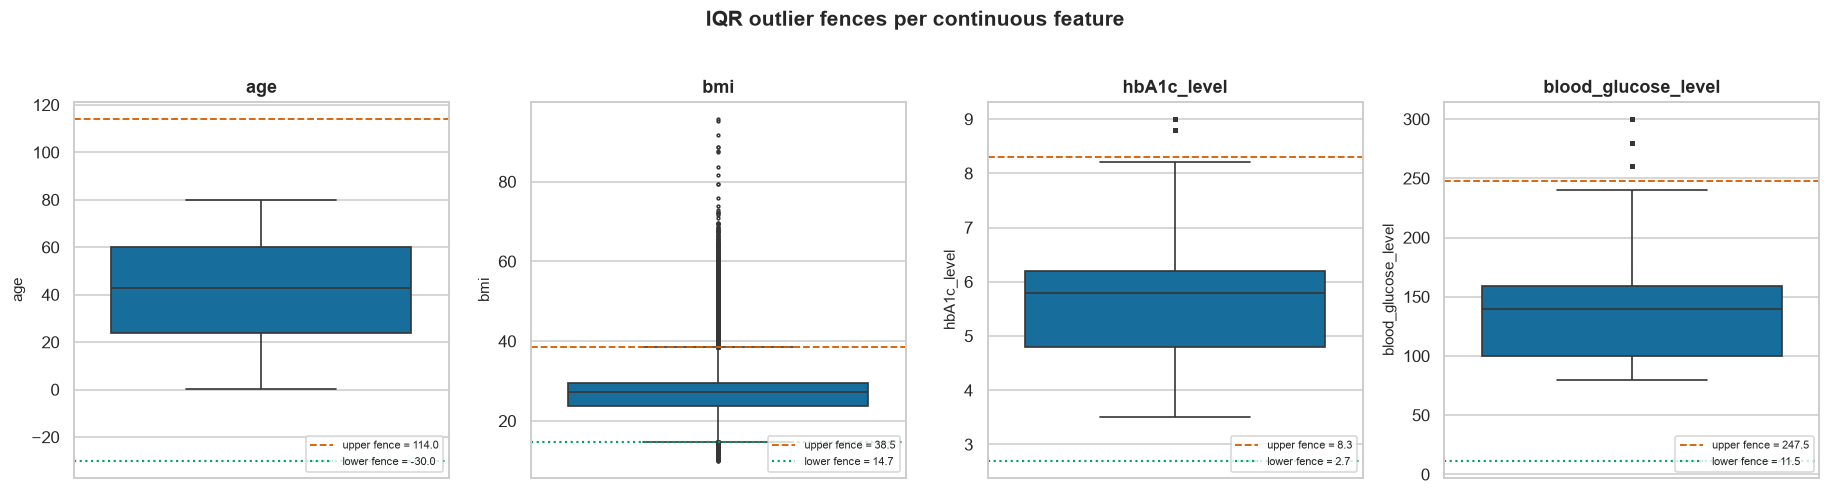

In [14]:
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(4.2 * len(outlier_cols), 4.4))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color=sns.color_palette(PALETTE)[0],
                fliersize=1.8, linewidth=1.1)
    lo, hi = iqr_bounds(df[col])
    ax.axhline(hi, color=sns.color_palette(PALETTE)[3], linestyle="--",
               linewidth=1.2, label=f"upper fence = {hi:.1f}")
    ax.axhline(lo, color=sns.color_palette(PALETTE)[2], linestyle=":",
               linewidth=1.4, label=f"lower fence = {lo:.1f}")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel(col)
    ax.legend(fontsize=7.5, loc="lower right")

fig.suptitle("IQR outlier fences per continuous feature",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Observation — 3.4

- IQR flags 1,315 outliers in `hbA1c_level` and 2,038 in `blood_glucose_level`.
- 100% of both groups are diabetic, against a baseline diabetes rate of 8.50% in the full frame.
- `bmi` has 7,086 flagged rows, 20.86% of them diabetic.
- `age` has no outliers at all; its fences fall outside the possible range of the column.
- The flagged HbA1c and glucose rows total 3,353 records, which is 39% of the 8,500 diabetic cases in the dataset.
- Treatment is winsorisation, using bounds recomputed on the training split in section 3.7.

## 3.5 Feature engineering

Three new features are added. All three are **strictly row-wise**: each is computed
from that record's own values and nothing else. No statistic is calculated across
rows, so creating them before the train/test split leaks nothing.

### Feature 1 — `bmi_category`

`bmi` binned into the standard WHO bands: Underweight (<18.5), Normal (18.5–25),
Overweight (25–30), Obese_I (30–35), Obese_II+ (>=35).

**Why it might help.** The relationship between BMI and diabetes risk is not a
straight line. Risk does not creep up evenly with every BMI point; it steps up
sharply once a patient crosses into obesity. A linear model handed raw `bmi` can
only fit one constant slope and cannot express that step. Giving it explicit bands
lets Logistic Regression and Naive Bayes use a non-linearity they otherwise cannot
represent. It also absorbs the repeated 27.32 value noted in section 2.1 into a
single band rather than leaving it as a spike.

### Feature 2 — `age_risk_interaction` = `age` × `hbA1c_level` / 100

**Why it might help.** Risk is not simply additive in age and glycaemic level. An
elevated HbA1c in a 70-year-old carries different weight from the same reading in a
25-year-old. A linear model cannot represent the product of two inputs unless that
product is supplied explicitly, so this hands it an interaction effect it could not
otherwise see. Dividing by 100 keeps the values on a similar order of magnitude to
the other features before scaling.

### Feature 3 — `metabolic_risk_score`

A count of how many clinical risk flags a patient carries: HbA1c >= 5.7 (the
pre-diabetic threshold), glucose >= 140, BMI >= 30, hypertension, and heart disease.
The score runs 0 to 5.

**Why it might help.** It compresses five individually weak signals into one ordinal
"how many risk factors does this patient have" variable. This is particularly useful
for Gaussian Naive Bayes, whose independence assumption prevents it from combining
co-occurring flags on its own.

**Why it is leakage-free.** The thresholds are fixed clinical constants taken from
the medical literature, not quantiles computed from this dataset. Nothing about the
data, and therefore nothing about the test split, influences where the cut-offs sit.

In [15]:
def engineer_features(frame):
    '''Add the three engineered features.

    Every calculation uses only values from within the same row, so this is safe
    to run before the train/test split.
    '''
    out = frame.copy()

    # WHO bands. risk steps up at obesity rather than rising smoothly per BMI point,
    # and a linear model given raw bmi can only fit one constant slope
    out["bmi_category"] = pd.cut(
        out["bmi"],
        bins=[-np.inf, 18.5, 25.0, 30.0, 35.0, np.inf],
        labels=["Underweight", "Normal", "Overweight", "Obese_I", "Obese_II+"],
    ).astype(str)

    # a linear model cannot represent age x hbA1c unless the product is handed to it
    out["age_risk_interaction"] = (out["age"] * out["hbA1c_level"]) / 100.0

    # thresholds are fixed clinical constants from the literature, NOT quantiles
    # computed from this dataset - that is what keeps this leakage-free
    out["metabolic_risk_score"] = (
        (out["hbA1c_level"]         >= 5.7).astype(int) +
        (out["blood_glucose_level"] >= 140).astype(int) +
        (out["bmi"]                 >= 30).astype(int) +
        out["hypertension"].astype(int) +
        out["heart_disease"].astype(int)
    )
    return out


df = engineer_features(df)

print("Added: bmi_category, age_risk_interaction, metabolic_risk_score")
print("Shape:", df.shape)
df[["bmi", "bmi_category", "age", "hbA1c_level",
    "age_risk_interaction", "metabolic_risk_score"]].head()

Added: bmi_category, age_risk_interaction, metabolic_risk_score
Shape: (99986, 15)


,bmi,bmi_category,age,hbA1c_level,age_risk_interaction,metabolic_risk_score
0,27.32,Overweight,32.0,5.0,1.600,0
1,19.95,Normal,29.0,5.0,1.450,0
2,23.76,Normal,18.0,4.8,0.864,1
3,27.32,Overweight,41.0,4.0,1.640,1
4,23.75,Normal,52.0,6.5,3.380,1


### Do the new features actually separate the classes?

A feature only earns its place if the diabetes rate changes across its values. Both
tables below report prevalence per level, so the relationship can be read directly.

In [16]:
band_order = ["Underweight", "Normal", "Overweight", "Obese_I", "Obese_II+"]
band_order = [b for b in band_order if b in df["bmi_category"].unique()]

bmi_tab = (df.groupby("bmi_category")
             .agg(n_records=(TARGET, "size"),
                  diabetes_rate_pct=(TARGET, lambda s: round(s.mean() * 100, 2)))
             .reindex(band_order))
print("Diabetes rate by bmi_category:")
print(bmi_tab.to_string())

risk_tab = df.groupby("metabolic_risk_score").agg(
    n_records=(TARGET, "size"),
    diabetes_rate_pct=(TARGET, lambda s: round(s.mean() * 100, 2)),
)
print("\nDiabetes rate by metabolic_risk_score:")
print(risk_tab.to_string())

# how does the interaction term compare with its two parent columns?
print("\nCorrelation with the target:")
for col in ["age", "hbA1c_level", "age_risk_interaction", "metabolic_risk_score"]:
    print(f"  {col:<22} {df[col].corr(df[TARGET]):+.4f}")

Diabetes rate by bmi_category:
              n_records  diabetes_rate_pct
bmi_category                              
Underweight        8521               0.75
Normal            22291               3.89
Overweight        45691               7.30
Obese_I           12717              14.52
Obese_II+         10766              22.16

Diabetes rate by metabolic_risk_score:
                      n_records  diabetes_rate_pct
metabolic_risk_score                              
0                         12847               0.00
1                         37754               1.14
2                         35262               8.61
3                         11524              30.48
4                          2393              57.54
5                           206              68.93

Correlation with the target:
  age                    +0.2580
  hbA1c_level            +0.4007
  age_risk_interaction   +0.4106
  metabolic_risk_score   +0.3851


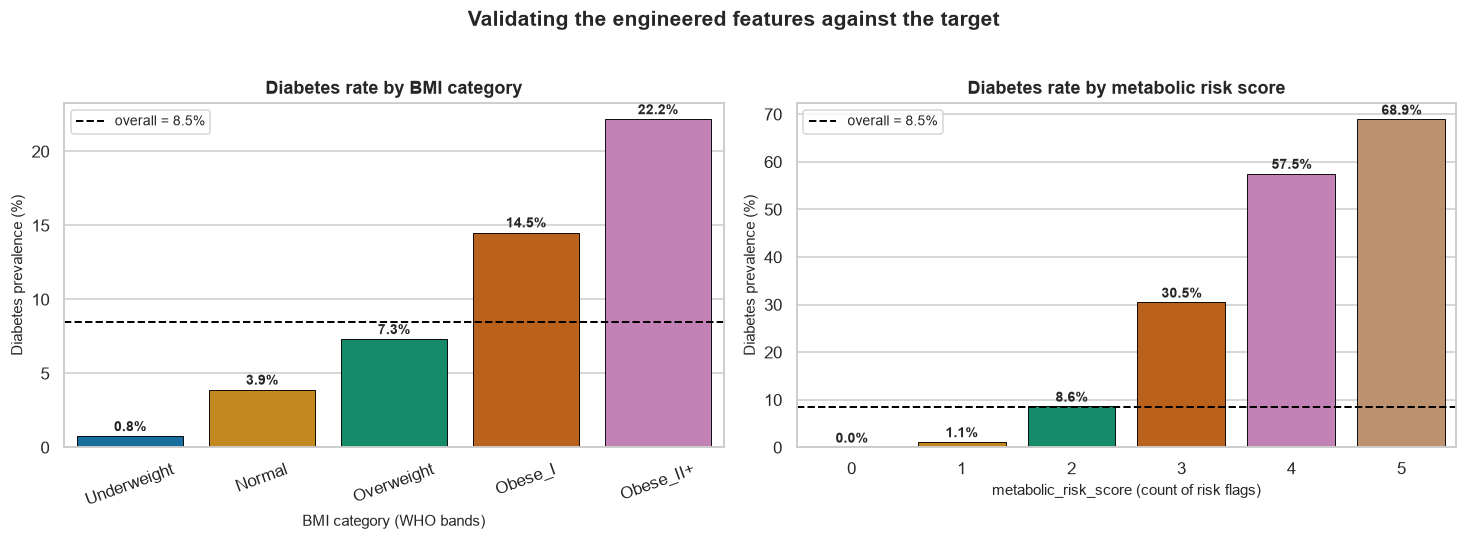

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

rate_bmi = df.groupby("bmi_category")[TARGET].mean().reindex(band_order) * 100
sns.barplot(x=rate_bmi.index, y=rate_bmi.values, ax=axes[0],
            hue=rate_bmi.index, legend=False,
            palette=PALETTE, edgecolor="black", linewidth=0.6)
axes[0].axhline(df[TARGET].mean() * 100, color="black", linestyle="--",
                linewidth=1.3, label=f"overall = {df[TARGET].mean()*100:.1f}%")
axes[0].set_title("Diabetes rate by BMI category")
axes[0].set_xlabel("BMI category (WHO bands)")
axes[0].set_ylabel("Diabetes prevalence (%)")
axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(rate_bmi.values):
    axes[0].text(i, v + 0.35, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

rate_risk = df.groupby("metabolic_risk_score")[TARGET].mean() * 100
sns.barplot(x=rate_risk.index.astype(str), y=rate_risk.values, ax=axes[1],
            hue=rate_risk.index.astype(str), legend=False,
            palette=PALETTE, edgecolor="black", linewidth=0.6)
axes[1].axhline(df[TARGET].mean() * 100, color="black", linestyle="--",
                linewidth=1.3, label=f"overall = {df[TARGET].mean()*100:.1f}%")
axes[1].set_title("Diabetes rate by metabolic risk score")
axes[1].set_xlabel("metabolic_risk_score (count of risk flags)")
axes[1].set_ylabel("Diabetes prevalence (%)")
axes[1].legend(fontsize=9)
for i, v in enumerate(rate_risk.values):
    axes[1].text(i, v + 1.0, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

fig.suptitle("Validating the engineered features against the target",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Observation — 3.5

- Diabetes prevalence by `bmi_category` runs 0.75%, 3.89%, 7.30%, 14.52%, 22.16% across the five WHO bands.
- Prevalence by `metabolic_risk_score` runs 0.00%, 1.14%, 8.61%, 30.48%, 57.54%, 68.93% for scores 0 through 5.
- Both sequences increase at every step, and the size of the steps grows rather than staying constant.
- Correlation with the target: `age_risk_interaction` +0.4106, `hbA1c_level` +0.4007, `metabolic_risk_score` +0.3851, `age` +0.2580.
- `age_risk_interaction` correlates more strongly with the target than either of the two columns it is built from.

## 3.6 Train/test split

The split happens now, before any transformer is fitted. Everything after this
point that estimates a parameter sees `X_train` only.

`stratify=y` forces both partitions to keep the same 8.5% diabetic rate. Without
it, an 8.5% minority class can drift by a full percentage point purely by chance,
which makes the metric comparison between models unreliable.

In [18]:
from sklearn.model_selection import train_test_split

FEATURES_TO_DROP = [TARGET]
if "year" in df.columns:
    # section 2.2 showed r = -0.0035 with the target and no relationship with any
    # predictor, so it adds a dimension without adding information
    FEATURES_TO_DROP.append("year")
    print("Dropping 'year': administrative field, no predictive signal")

X = df.drop(columns=FEATURES_TO_DROP)
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,               # keeps the 8.5% minority rate in both halves
    random_state=RANDOM_STATE,
)

print(f"\nX_train : {X_train.shape[0]:,} rows x {X_train.shape[1]} columns")
print(f"X_test  : {X_test.shape[0]:,} rows x {X_test.shape[1]} columns")

# proof that stratification worked
split_check = pd.DataFrame({
    "full_%":  (y.value_counts(normalize=True).sort_index() * 100).round(3),
    "train_%": (y_train.value_counts(normalize=True).sort_index() * 100).round(3),
    "test_%":  (y_test.value_counts(normalize=True).sort_index() * 100).round(3),
    "train_n": y_train.value_counts().sort_index(),
    "test_n":  y_test.value_counts().sort_index(),
})
print("\nClass proportions are preserved across both splits:")
print(split_check.to_string())

Dropping 'year': administrative field, no predictive signal

X_train : 79,988 rows x 13 columns
X_test  : 19,998 rows x 13 columns

Class proportions are preserved across both splits:
          full_%  train_%  test_%  train_n  test_n
diabetes                                          
0         91.499   91.499  91.499    73188   18298
1          8.501    8.501   8.501     6800    1700


## 3.7 Preprocessing, fitted on the training split only

This is the cell where leakage would happen if the discipline slipped, so every
fitted object is created explicitly and each `.fit()` call is visibly restricted to
the training data.

### Encoding

| Column | Encoding | Reason |
|--------|----------|--------|
| `gender`, `smoking_history`, `race`, `bmi_category` | One-hot | Low cardinality, nominal, no natural ordering |
| `location` | **Frequency** | See below |

**Why `location` is frequency-encoded rather than one-hot.** It has 54 levels. One-hot
would grow the design matrix from roughly 24 columns to roughly 75, and every added
column would be sparse and carry almost no class-rate variation. That hurts this
particular model set in two concrete ways: **KNN** measures Euclidean distance, and
54 near-orthogonal sparse dimensions dilute the informative distance contributed by
HbA1c and glucose; **SVC** cost grows with dimensionality. Frequency encoding maps
each state to how often it appears **in the training split**, giving one dense
numeric column instead.

**Target encoding was rejected.** It replaces each category with the mean target
value for that category, which uses the label to build the feature. That is a
classic leakage route.

### Scaling

`StandardScaler` rescales each column to mean 0 and standard deviation 1. KNN and
SVC need this: without it `blood_glucose_level`, which runs 80 to 300, would
overwhelm `hbA1c_level`, which runs 3 to 9, purely because of the units they happen
to be measured in. Decision trees are unaffected either way since they split on
thresholds, but everything is scaled for consistency.

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# declare which columns get which treatment
onehot_cols = [c for c in ["gender", "smoking_history", "race", "bmi_category"]
               if c in X_train.columns]
freq_cols = [c for c in ["location"] if c in X_train.columns]
numeric_cols = [c for c in X_train.columns if c not in onehot_cols + freq_cols]

print("One-hot   :", onehot_cols)
print("Frequency :", freq_cols)
print("Numeric   :", numeric_cols)

Xtr = X_train.copy()
Xte = X_test.copy()

# ---- step 1: imputation -------------------------------------------------
# median for numeric because bmi and glucose are right-skewed and the mean
# would be dragged toward the tail
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

# fit_transform on TRAIN, transform on TEST. fitting on the full frame would let
# test rows influence the imputation values, which is leakage
Xtr[numeric_cols] = num_imputer.fit_transform(Xtr[numeric_cols])
Xte[numeric_cols] = num_imputer.transform(Xte[numeric_cols])

cat_all = onehot_cols + freq_cols
if cat_all:
    Xtr[cat_all] = cat_imputer.fit_transform(Xtr[cat_all])
    Xte[cat_all] = cat_imputer.transform(Xte[cat_all])

print(f"\n[1] Imputers fitted on {len(Xtr):,} training rows only")

One-hot   : ['gender', 'smoking_history', 'race', 'bmi_category']
Frequency : ['location']
Numeric   : ['age', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'age_risk_interaction', 'metabolic_risk_score']

[1] Imputers fitted on 79,988 training rows only


In [20]:
# ---- step 2: outlier winsorisation --------------------------------------
# bounds recomputed here from TRAIN only. Q1 and Q3 are statistics, so deriving
# them from the full frame would leak the test distribution
winsor_cols = [c for c in ["bmi", "hbA1c_level", "blood_glucose_level"]
               if c in numeric_cols]
train_bounds = {}

for col in winsor_cols:
    lo, hi = iqr_bounds(Xtr[col])
    train_bounds[col] = (lo, hi)
    n_tr = int(((Xtr[col] < lo) | (Xtr[col] > hi)).sum())
    n_te = int(((Xte[col] < lo) | (Xte[col] > hi)).sum())
    # clip, do not delete: section 3.4 showed these rows are 100% diabetic
    Xtr[col] = Xtr[col].clip(lo, hi)
    Xte[col] = Xte[col].clip(lo, hi)
    print(f"[2] {col:<22} bounds=({lo:.2f}, {hi:.2f})  clipped: {n_tr:,} train / {n_te:,} test")

[2] bmi                    bounds=(14.72, 38.53)  clipped: 5,697 train / 1,383 test
[2] hbA1c_level            bounds=(2.70, 8.30)  clipped: 1,039 train / 276 test
[2] blood_glucose_level    bounds=(11.50, 247.50)  clipped: 1,632 train / 406 test


In [21]:
# ---- step 3: frequency encoding for location ----------------------------
for col in freq_cols:
    # the map is built from TRAIN frequencies only
    freq_map = Xtr[col].value_counts(normalize=True)
    Xtr[col + "_freq"] = Xtr[col].map(freq_map).astype(float)
    # a state appearing only in the test split has no training frequency -> 0.0
    Xte[col + "_freq"] = Xte[col].map(freq_map).fillna(0.0).astype(float)
    unseen = int(Xte[col + "_freq"].eq(0.0).sum())
    print(f"[3] {col}: {len(freq_map)} levels learned from train, "
          f"{unseen} test rows had an unseen level")
    Xtr = Xtr.drop(columns=[col])
    Xte = Xte.drop(columns=[col])

numeric_cols = numeric_cols + [c + "_freq" for c in freq_cols]

# ---- step 4: one-hot encoding -------------------------------------------
# handle_unknown='ignore' so a category appearing only in test degrades quietly
# instead of crashing; drop='first' avoids the dummy variable trap
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
ohe_train = ohe.fit_transform(Xtr[onehot_cols])
ohe_test = ohe.transform(Xte[onehot_cols])
ohe_names = list(ohe.get_feature_names_out(onehot_cols))

print(f"\n[4] OneHotEncoder fitted on train -> {len(ohe_names)} indicator columns")

[3] location: 55 levels learned from train, 0 test rows had an unseen level



[4] OneHotEncoder fitted on train -> 15 indicator columns


In [22]:
# ---- step 5: standardisation --------------------------------------------
# mean and std come from TRAIN only, then the SAME numbers transform both halves
scaler = StandardScaler()
num_train = scaler.fit_transform(Xtr[numeric_cols])
num_test = scaler.transform(Xte[numeric_cols])

print("[5] StandardScaler fitted on train only. Learned statistics:")
print(pd.DataFrame({
    "feature":    numeric_cols,
    "train_mean": np.round(scaler.mean_, 3),
    "train_std":  np.round(np.sqrt(scaler.var_), 3),
}).to_string(index=False))

# ---- step 6: assemble the final matrices --------------------------------
feature_names = numeric_cols + ohe_names
X_train_proc = pd.DataFrame(np.hstack([num_train, ohe_train]),
                            columns=feature_names, index=Xtr.index)
X_test_proc = pd.DataFrame(np.hstack([num_test, ohe_test]),
                           columns=feature_names, index=Xte.index)

print(f"\n[6] X_train_proc : {X_train_proc.shape}")
print(f"    X_test_proc  : {X_test_proc.shape}")

[5] StandardScaler fitted on train only. Learned statistics:
             feature  train_mean  train_std
                 age      41.844     22.483
        hypertension       0.074      0.262
       heart_disease       0.039      0.193
                 bmi      27.006      5.674
         hbA1c_level       5.521      1.048
 blood_glucose_level     137.458     38.460
age_risk_interaction       2.337      1.399
metabolic_risk_score       1.535      0.950
       location_freq       0.019      0.003

[6] X_train_proc : (79988, 24)
    X_test_proc  : (19998, 24)


### Verifying that no leakage occurred

If the scaler had been fitted on the full dataset, the **test** columns would also
come out centred at exactly 0 with standard deviation exactly 1. Because it was
fitted on training data only, the training columns are exactly standardised while
the test columns deviate slightly. **That small deviation is the positive evidence
that the discipline held.**

In [23]:
check = pd.DataFrame({
    "train_mean": X_train_proc[numeric_cols].mean().round(6),
    "train_std":  X_train_proc[numeric_cols].std(ddof=0).round(6),
    "test_mean":  X_test_proc[numeric_cols].mean().round(6),
    "test_std":   X_test_proc[numeric_cols].std(ddof=0).round(6),
})
print(check.to_string())

# if this fails the scaler was never fitted on train, and every metric is suspect
assert np.allclose(X_train_proc[numeric_cols].mean(), 0, atol=1e-9), \
    "train means are not zero - scaler was not fitted on train"

# test means being exactly zero would mean the scaler saw test rows. the slight
# deviation is the positive evidence that it did not
assert not np.allclose(X_test_proc[numeric_cols].mean(), 0, atol=1e-9), \
    "test means are exactly zero - scaler appears to have been fitted on test data"

assert X_train_proc.isna().sum().sum() == 0, "NaNs in processed train matrix"
assert X_test_proc.isna().sum().sum() == 0, "NaNs in processed test matrix"
assert list(X_train_proc.columns) == list(X_test_proc.columns), "column mismatch"

print("\nAll leakage and integrity assertions passed.")

                      train_mean  train_std  test_mean  test_std
age                         -0.0        1.0   0.009307  1.007424
hypertension                -0.0        1.0   0.008799  1.014132
heart_disease               -0.0        1.0   0.013437  1.031456
bmi                          0.0        1.0  -0.011238  0.999537
hbA1c_level                 -0.0        1.0  -0.004833  0.999551
blood_glucose_level         -0.0        1.0  -0.008899  1.006024
age_risk_interaction        -0.0        1.0   0.009168  1.007402
metabolic_risk_score        -0.0        1.0  -0.003924  1.006391
location_freq                0.0        1.0  -0.015575  1.017347

All leakage and integrity assertions passed.


### Observation — 3.7

- The split gives 79,988 training rows and 19,998 test rows, both holding 8.501% diabetic.
- Training columns come out with mean 0 and standard deviation 1 to within 1e-9.
- Test columns do not; their means sit slightly away from zero.
- The assertion fails if the test means are exactly zero, which would indicate the scaler had been fitted on all the data.
- The final design matrix has 24 columns. One-hot encoding `location` instead would have produced roughly 75.

---
# 4. Model Training

Five classifiers, each seeded with `random_state=42` where the estimator accepts one.

### Tuning protocol

Hyperparameters are searched with `GridSearchCV` using 3-fold stratified
cross-validation **on the training split only** - the test set is never touched
during model selection.

Scoring uses **F1 on the diabetic class**, not accuracy. Under a 10.76 to 1
imbalance a grid optimised for accuracy would happily select a model that never
predicts a diabetic patient, because that already scores 91.5%.

### Computational budget

KNN prediction cost scales with `n_train x n_test`, and kernel-SVM training scales
between O(n^2) and O(n^3). An exhaustive grid over 80,000 rows would run for hours,
so both are tuned on a stratified subsample and the winning configuration is refit
on a larger one. The sizes are printed rather than hidden. Their reported scores
are therefore conservative lower bounds.

In [24]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
import time

models = {}       # fitted estimator per algorithm
fit_times = {}    # seconds to fit, for the comparison table
best_params = {}  # chosen hyperparameters

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def subsample(X, y, n, seed=RANDOM_STATE):
    '''Stratified subsample, used to keep KNN and SVC tractable.'''
    if n >= len(X):
        return X, y
    X_s, _, y_s, _ = train_test_split(X, y, train_size=n, stratify=y, random_state=seed)
    return X_s, y_s


print(f"Training rows : {len(X_train_proc):,}")
print(f"Test rows     : {len(X_test_proc):,}")
print(f"Features      : {X_train_proc.shape[1]}")

Training rows : 79,988
Test rows     : 19,998
Features      : 24


## 4.1 Logistic Regression

A linear baseline. It models the log-odds of diabetes as a weighted sum of the
features. Its value here is **interpretability**: exponentiating a coefficient turns
it into an **odds ratio**, which says how the odds of diabetes multiply per one
standard deviation increase in that feature. Because everything was standardised in
3.7, the coefficients are directly comparable to each other.

In [25]:
t0 = time.perf_counter()

# left at defaults: C and penalty were not tuned, which was a scope decision
logreg = LogisticRegression(max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE)
logreg.fit(X_train_proc, y_train)

fit_times["Logistic Regression"] = time.perf_counter() - t0
models["Logistic Regression"] = logreg
best_params["Logistic Regression"] = {"solver": "lbfgs", "C": 1.0, "max_iter": 2000}

print(f"Converged in {logreg.n_iter_[0]} iterations "
      f"({fit_times['Logistic Regression']:.2f}s)")
print(f"Intercept: {logreg.intercept_[0]:.4f}")

Converged in 57 iterations (0.10s)
Intercept: -5.7587


In [26]:
# exp(coefficient) converts a log-odds weight into an odds ratio:
# >1 increases the odds of diabetes, <1 decreases them
odds = pd.DataFrame({"feature": feature_names, "coefficient": logreg.coef_[0]})
odds["odds_ratio"] = np.exp(odds["coefficient"])
odds["direction"] = np.where(odds["coefficient"] > 0, "increases risk", "decreases risk")
odds = odds.reindex(odds["coefficient"].abs().sort_values(ascending=False).index)

print("Coefficients as odds ratios, ranked by effect size:\n")
print(odds.round(4).to_string(index=False))

Coefficients as odds ratios, ranked by effect size:

                    feature  coefficient  odds_ratio      direction
                hbA1c_level       2.8144     16.6834 increases risk
        blood_glucose_level       1.5673      4.7936 increases risk
                        age       1.3519      3.8648 increases risk
       metabolic_risk_score      -0.7546      0.4702 decreases risk
     bmi_category_Obese_II+       0.7343      2.0841 increases risk
       bmi_category_Obese_I       0.7074      2.0287 increases risk
    smoking_history_current       0.6936      2.0009 increases risk
                        bmi       0.6866      1.9870 increases risk
       smoking_history_ever       0.6609      1.9364 increases risk
     smoking_history_former       0.5527      1.7379 increases risk
      smoking_history_never       0.5277      1.6951 increases risk
smoking_history_not current       0.5099      1.6652 increases risk
   bmi_category_Underweight       0.5040      1.6553 increases 

## 4.2 K-Nearest Neighbours

Classifies a patient by majority vote among the `k` closest records in feature
space. It makes **no assumption about the shape of the decision boundary**, which
suits the threshold-like structure seen in section 2.4.

### Distance metric

The grid searches both Minkowski options:

- **Euclidean (p=2)** - straight-line distance, the natural default for continuous
  standardised measurements.
- **Manhattan (p=1)** - sum of absolute differences. More robust in higher
  dimensions and less dominated by one large coordinate gap, which should matter
  here because the matrix mixes continuous features with binary one-hot columns.

Standardisation is a **precondition** for either: without it `blood_glucose_level`,
ranging 80 to 300, would swamp `hbA1c_level`, ranging 3 to 9, purely through units.

In [27]:
KNN_TUNE_N = 12_000   # subsample for the grid search
KNN_FIT_N  = 40_000   # subsample the winner is refit on

X_knn_tune, y_knn_tune = subsample(X_train_proc, y_train, KNN_TUNE_N)
print(f"Tuning KNN on {len(X_knn_tune):,} stratified rows "
      f"(positive rate {y_knn_tune.mean()*100:.2f}% vs {y_train.mean()*100:.2f}% in full train)\n")

knn_grid = {
    "n_neighbors": [3, 5, 9, 15, 21, 31],
    "weights":     ["uniform", "distance"],
    "p":           [1, 2],   # 1 = Manhattan, 2 = Euclidean
}

t0 = time.perf_counter()
# scoring='f1' targets the diabetic class. optimising accuracy would reward a
# model that never predicts a diabetic patient
knn_search = GridSearchCV(KNeighborsClassifier(n_jobs=-1), knn_grid,
                          scoring="f1", cv=cv, n_jobs=-1)
knn_search.fit(X_knn_tune, y_knn_tune)

print(f"Searched {len(knn_search.cv_results_['params'])} configurations "
      f"in {time.perf_counter() - t0:.1f}s")
print("Best parameters :", knn_search.best_params_)
print(f"Best CV F1      : {knn_search.best_score_:.4f}")

res = pd.DataFrame(knn_search.cv_results_)
print("\nMean CV F1 by distance metric:")
print(res.groupby("param_p")["mean_test_score"]
         .mean().rename(index={1: "Manhattan (p=1)", 2: "Euclidean (p=2)"})
         .round(4).to_string())
print("\nBest CV F1 by k:")
print(res.groupby("param_n_neighbors")["mean_test_score"].max().round(4).to_string())

Tuning KNN on 12,000 stratified rows (positive rate 8.50% vs 8.50% in full train)



Searched 24 configurations in 3.8s
Best parameters : {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
Best CV F1      : 0.6594

Mean CV F1 by distance metric:
param_p
Manhattan (p=1)    0.5662
Euclidean (p=2)    0.6367

Best CV F1 by k:
param_n_neighbors
3     0.6594
5     0.6592
9     0.6380
15    0.6362
21    0.6289
31    0.6157


In [28]:
X_knn_fit, y_knn_fit = subsample(X_train_proc, y_train, KNN_FIT_N)

t0 = time.perf_counter()
knn = KNeighborsClassifier(**knn_search.best_params_, n_jobs=-1)
knn.fit(X_knn_fit, y_knn_fit)
fit_times["K-Nearest Neighbors"] = time.perf_counter() - t0

models["K-Nearest Neighbors"] = knn
best_params["K-Nearest Neighbors"] = knn_search.best_params_
print(f"Refit on {len(X_knn_fit):,} rows in {fit_times['K-Nearest Neighbors']:.2f}s")

Refit on 40,000 rows in 0.00s


### Observation — 4.2

- The grid selected `k=3`, `weights='uniform'`, Euclidean (`p=2`).
- Cross-validated F1 falls as k grows: 0.6594 at k=3 down to 0.6157 at k=31.
- Mean CV F1 was 0.6367 for Euclidean against 0.5662 for Manhattan.
- `k=3` is the smallest value searched, so the optimum sits at the edge of the grid.

## 4.3 Gaussian Naive Bayes

A generative classifier applying Bayes' theorem under a strong simplifying
assumption.

### The conditional independence assumption

Gaussian NB assumes that, **given the class label**, every feature is statistically
independent of every other, and that each is normally distributed within each class:

$$P(x_1, \ldots, x_n \mid y) = \prod_{i=1}^{n} P(x_i \mid y)$$

That assumption makes it fast and hyperparameter-free. It is also **clearly violated
by this dataset**, in four ways:

1. **The features are correlated.** Section 2.2 showed HbA1c and glucose move
   together, since both measure glycaemic state. NB treats them as two independent
   pieces of evidence and so **double-counts** the same underlying signal.
2. **The engineered features are deterministic functions of their parents.**
   `age_risk_interaction` is literally `age x hbA1c_level`, and
   `metabolic_risk_score` is built from five columns that are all present
   separately. That is maximal dependence, the opposite of the assumption.
3. **Normality fails.** Section 2.1 showed both glycaemic markers are discretised
   into 18 values and right-skewed, not Gaussian.
4. **The one-hot columns are binary**, not continuous, so fitting a Gaussian to them
   is a crude approximation.

**Why include it anyway.** Naive Bayes often still ranks cases correctly even when
its assumptions fail, because correct ranking only needs the ordering of the
posteriors to hold, not their calibration. It serves as a fast probabilistic
baseline and as a concrete demonstration of what happens when a model's assumptions
are mismatched to its data.

In [29]:
t0 = time.perf_counter()

gnb = GaussianNB()   # no random_state: the fit is entirely deterministic
gnb.fit(X_train_proc, y_train)

fit_times["Gaussian Naive Bayes"] = time.perf_counter() - t0
models["Gaussian Naive Bayes"] = gnb
best_params["Gaussian Naive Bayes"] = {"var_smoothing": gnb.var_smoothing}

print(f"Fitted in {fit_times['Gaussian Naive Bayes']:.4f}s - closed form, no iteration")
print("Learned class priors:", dict(zip(gnb.classes_, np.round(gnb.class_prior_, 4))))
print("  (these mirror the training class balance, as expected)")

Fitted in 0.0127s - closed form, no iteration
Learned class priors: {np.int64(0): np.float64(0.915), np.int64(1): np.float64(0.085)}
  (these mirror the training class balance, as expected)


## 4.4 Decision Tree

A non-parametric model that recursively partitions the feature space using
axis-aligned threshold splits. Section 2.4 predicted this model would do well: the
diabetic region in HbA1c-glucose space is **rectangular and threshold-defined**,
which is exactly the geometry a tree represents natively rather than approximates.

`max_depth` is tuned because it is the main complexity control. Left unbounded the
tree grows until every leaf is pure, memorising the training data. A decision tree
is also **scale-invariant** - it splits on thresholds - so standardisation neither
helps nor hurts it.

In [30]:
dt_grid = {
    # unbounded depth memorises the training set, so this is the main control
    "max_depth":        [3, 4, 5, 6, 8, 10, 12, 15, None],
    "min_samples_leaf": [1, 5, 20],
    "criterion":        ["gini", "entropy"],
}

t0 = time.perf_counter()
dt_search = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                         dt_grid, scoring="f1", cv=cv, n_jobs=-1)
dt_search.fit(X_train_proc, y_train)

print(f"Searched {len(dt_search.cv_results_['params'])} configurations "
      f"in {time.perf_counter() - t0:.1f}s")
print("Best parameters :", dt_search.best_params_)
print(f"Best CV F1      : {dt_search.best_score_:.4f}")

t0 = time.perf_counter()
dtree = DecisionTreeClassifier(**dt_search.best_params_, random_state=RANDOM_STATE)
dtree.fit(X_train_proc, y_train)
fit_times["Decision Tree"] = time.perf_counter() - t0

models["Decision Tree"] = dtree
best_params["Decision Tree"] = dt_search.best_params_

print(f"\nFitted in {fit_times['Decision Tree']:.3f}s")
print("Depth  :", dtree.get_depth())
print("Leaves :", dtree.get_n_leaves())

Searched 54 configurations in 2.6s
Best parameters : {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 5}
Best CV F1      : 0.8019

Fitted in 0.103s
Depth  : 8
Leaves : 25


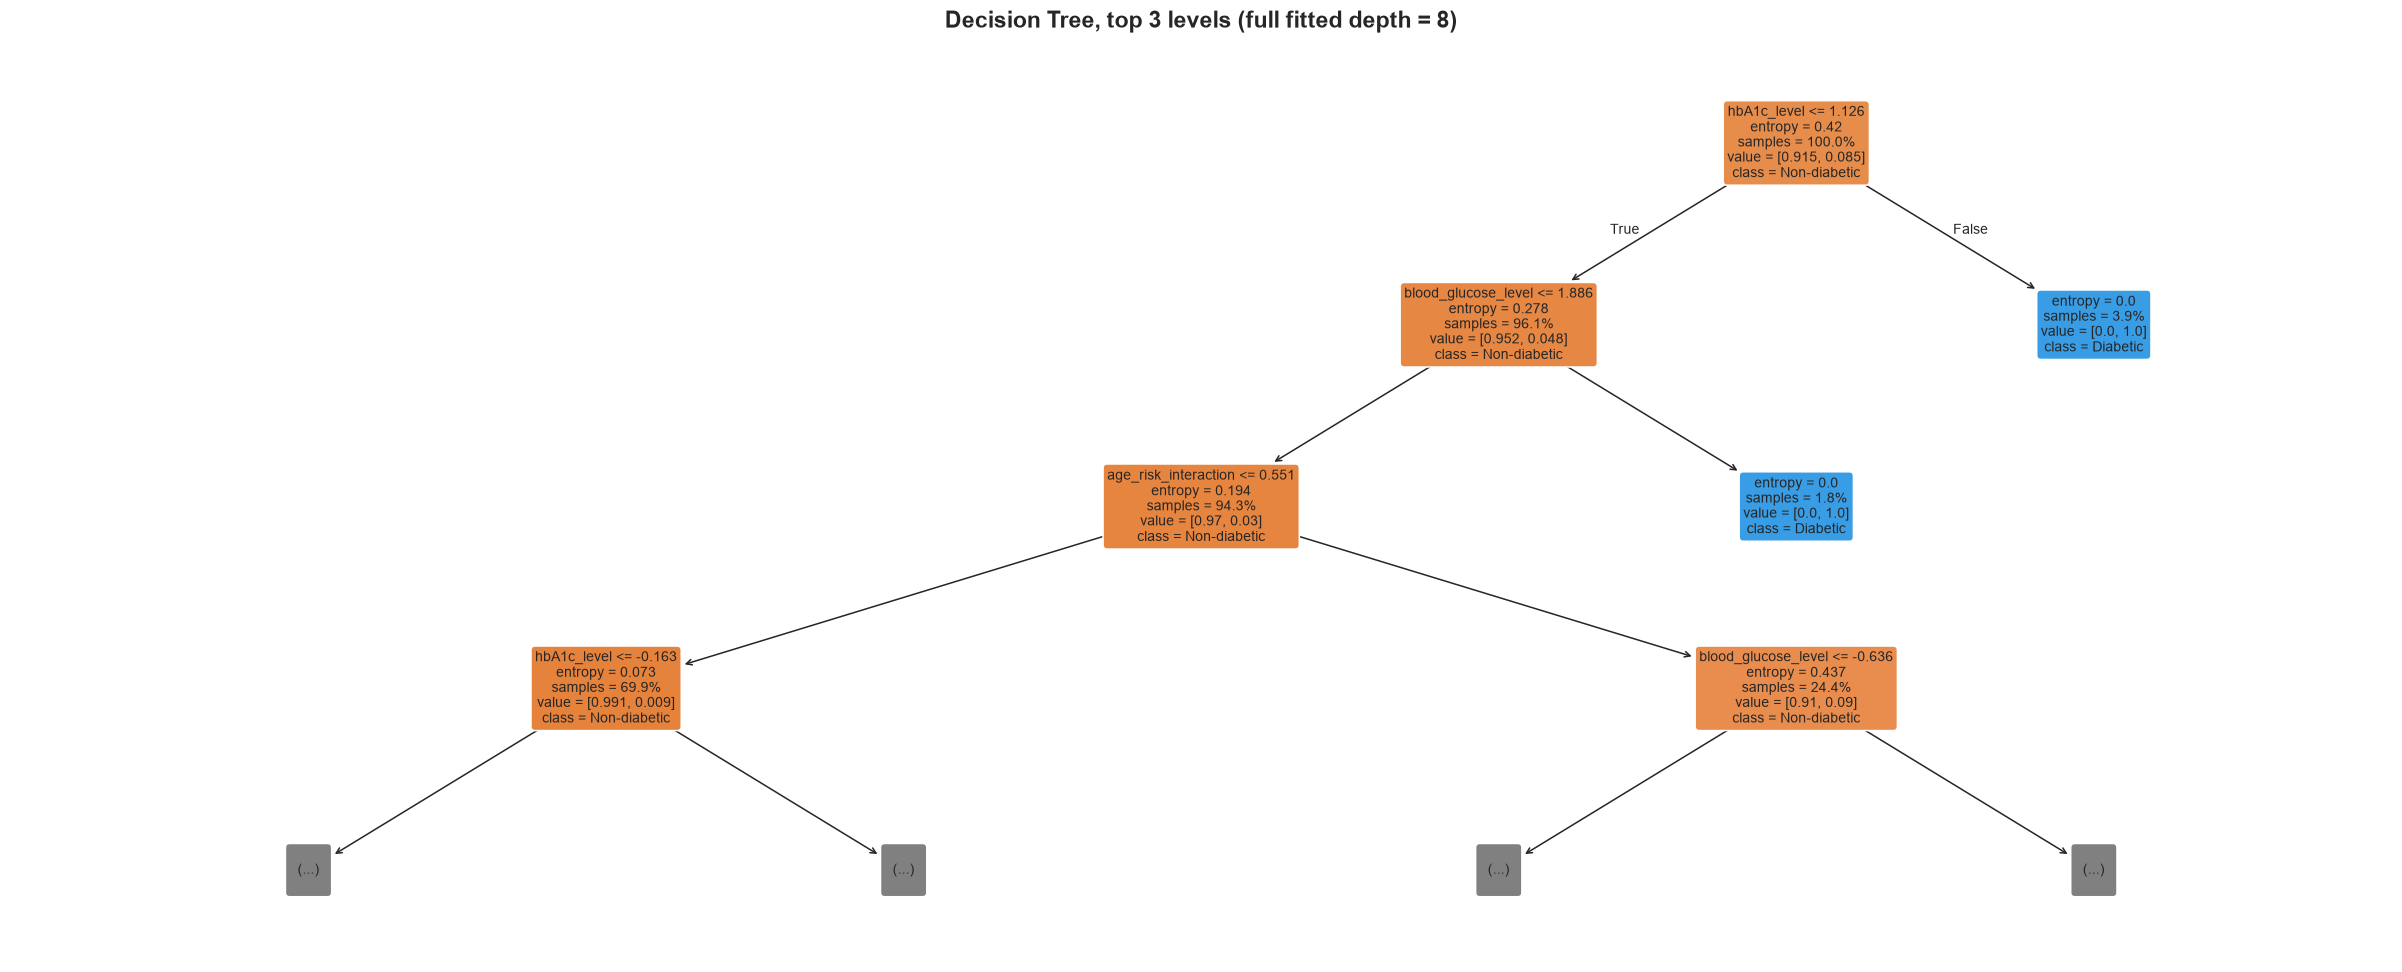

Features with non-zero importance:
             feature  importance
         hbA1c_level     0.54583
 blood_glucose_level     0.32643
age_risk_interaction     0.08706
metabolic_risk_score     0.02648
                 bmi     0.00957
                 age     0.00398
        hypertension     0.00049
       location_freq     0.00016

16 of 24 features were never used for a split - the tree performs implicit feature selection.


In [31]:
# only the first three levels: the full tree is too wide to read
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dtree, max_depth=3, feature_names=feature_names,
          class_names=["Non-diabetic", "Diabetic"],
          filled=True, rounded=True, proportion=True,
          fontsize=9, impurity=True, ax=ax)
ax.set_title(f"Decision Tree, top 3 levels (full fitted depth = {dtree.get_depth()})",
             fontsize=15, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

# how much each feature reduced impurity across the whole tree
imp = pd.DataFrame({"feature": feature_names,
                    "importance": dtree.feature_importances_}) \
        .sort_values("importance", ascending=False)
print("Features with non-zero importance:")
print(imp[imp["importance"] > 0].round(5).to_string(index=False))
print(f"\n{int((imp['importance'] == 0).sum())} of {len(imp)} features were never used "
      f"for a split - the tree performs implicit feature selection.")

### Observation — 4.4

- The root split is on `hbA1c_level`, with `blood_glucose_level` immediately below it.
- Selected parameters: `criterion='entropy'`, `max_depth=8`, `min_samples_leaf=5`, producing 25 leaves.
- `hbA1c_level` accounts for 0.546 of total impurity reduction and `blood_glucose_level` 0.326, together 87%.
- `age_risk_interaction` ranks third at 0.087 and `metabolic_risk_score` fourth at 0.026.
- 16 of the 24 features are never used for a split.

## 4.5 Support Vector Machine

An SVM finds the hyperplane that maximises the margin between the two classes. The
kernel trick lets it fit non-linear boundaries by operating implicitly in a
higher-dimensional space.

### Why SVMs require scaled features

The objective penalises the squared norm of the weight vector, and the RBF kernel
computes $\exp(-\gamma \|x - x'\|^2)$, a function of **Euclidean distance**. On raw
scales `blood_glucose_level` would contribute distances two orders of magnitude
larger than `hbA1c_level`, so the kernel would be driven almost entirely by glucose
and the margin defined in essentially one dimension. Scaling is a **precondition for
the model to work at all**, not a refinement.

### Kernels searched

`linear` (a straight hyperplane, fast, correct if the classes are close to
separable), `rbf` (smooth curved localised boundaries, the general-purpose default),
and `poly` at degree 3.

In [32]:
SVC_TUNE_N = 6_000    # kernel SVM training scales O(n^2) to O(n^3)
SVC_FIT_N  = 20_000

X_svc_tune, y_svc_tune = subsample(X_train_proc, y_train, SVC_TUNE_N)
print(f"Tuning SVC on {len(X_svc_tune):,} stratified rows "
      f"(positive rate {y_svc_tune.mean()*100:.2f}%)\n")

svc_grid = [
    {"kernel": ["linear"], "C": [0.1, 1.0, 10.0]},
    {"kernel": ["rbf"],    "C": [0.1, 1.0, 10.0], "gamma": ["scale", 0.1]},
    {"kernel": ["poly"],   "C": [1.0], "degree": [3], "gamma": ["scale"]},
]

t0 = time.perf_counter()
svc_search = GridSearchCV(SVC(random_state=RANDOM_STATE, cache_size=700),
                          svc_grid, scoring="f1", cv=cv, n_jobs=-1)
svc_search.fit(X_svc_tune, y_svc_tune)

print(f"Searched {len(svc_search.cv_results_['params'])} configurations "
      f"in {time.perf_counter() - t0:.1f}s")
print("Best parameters :", svc_search.best_params_)
print(f"Best CV F1      : {svc_search.best_score_:.4f}")

svc_res = pd.DataFrame(svc_search.cv_results_)
summary = (svc_res.groupby(["param_kernel", "param_C"])["mean_test_score"]
                  .max().reset_index()
                  .rename(columns={"param_kernel": "kernel", "param_C": "C",
                                   "mean_test_score": "best_CV_F1"}))
print("\nBest CV F1 by kernel and C:")
print(summary.sort_values("best_CV_F1", ascending=False).round(4).to_string(index=False))

Tuning SVC on 6,000 stratified rows (positive rate 8.50%)



Searched 10 configurations in 0.8s
Best parameters : {'C': 10.0, 'kernel': 'linear'}
Best CV F1      : 0.7004

Best CV F1 by kernel and C:
kernel    C  best_CV_F1
linear 10.0      0.7004
linear  1.0      0.6974
linear  0.1      0.6938
   rbf 10.0      0.6871
   rbf  1.0      0.6788
  poly  1.0      0.6741
   rbf  0.1      0.4554


In [33]:
X_svc_fit, y_svc_fit = subsample(X_train_proc, y_train, SVC_FIT_N)

t0 = time.perf_counter()
svc = SVC(**svc_search.best_params_, random_state=RANDOM_STATE, cache_size=700)
svc.fit(X_svc_fit, y_svc_fit)
fit_times["Support Vector Machine"] = time.perf_counter() - t0

models["Support Vector Machine"] = svc
best_params["Support Vector Machine"] = svc_search.best_params_

print(f"Refit on {len(X_svc_fit):,} rows in {fit_times['Support Vector Machine']:.1f}s")
# a low support-vector count means the margin is defined by few boundary cases,
# which indicates cleanly separated classes
print(f"Support vectors : {svc.n_support_.sum():,} "
      f"({svc.n_support_.sum() / len(X_svc_fit) * 100:.1f}% of the training sample)")
print("  per class     :", dict(zip(svc.classes_, svc.n_support_)))

Refit on 20,000 rows in 2.1s
Support vectors : 2,081 (10.4% of the training sample)
  per class     : {np.int64(0): np.int32(1041), np.int64(1): np.int32(1040)}


### Observation — 4.5

- The grid selected the linear kernel with `C=10.0`.
- Best CV F1 by kernel: linear 0.6938 to 0.7004, rbf 0.4554 to 0.6871, poly 0.6741.
- Every linear configuration scored above every rbf and poly configuration.
- The fitted model keeps 2,081 support vectors, 10.4% of its 20,000-row training sample, split 1,041 to 1,040 across the classes.

## 4.6 Save the fitted models

All five estimators and the fitted preprocessing objects are serialised so results
can be reproduced without retraining. `models/` is git-ignored because everything in
it rebuilds from this notebook.

In [34]:
import joblib

MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

for name, model in models.items():
    fname = name.lower().replace(" ", "_").replace("-", "_") + ".joblib"
    joblib.dump(model, os.path.join(MODEL_DIR, fname))
    print("saved", fname)

# the transformers matter as much as the models: new data must be preprocessed
# with the SAME fitted objects, not refitted ones
joblib.dump({
    "num_imputer": num_imputer, "cat_imputer": cat_imputer,
    "onehot_encoder": ohe, "scaler": scaler,
    "iqr_bounds": train_bounds, "feature_names": feature_names,
    "onehot_cols": onehot_cols, "numeric_cols": numeric_cols,
    "random_state": RANDOM_STATE,
}, os.path.join(MODEL_DIR, "preprocessing_pipeline.joblib"))
print("saved preprocessing_pipeline.joblib")

print(f"\nAll {len(models)} models trained and saved.")

saved logistic_regression.joblib
saved k_nearest_neighbors.joblib
saved gaussian_naive_bayes.joblib
saved decision_tree.joblib
saved support_vector_machine.joblib
saved preprocessing_pipeline.joblib

All 5 models trained and saved.


---
# 5. Evaluation

Every model is scored on the **same held-out test set**, which no model and no
transformer has seen at any point.

## 5.1 Computing the metrics

All five are evaluated in one loop and collected into a single DataFrame, rather
than scattered print statements. Alongside the weighted metrics the table also
reports **precision, recall and F1 on the diabetic class specifically**, because
under a 10.76 to 1 imbalance the weighted figures are dominated by the majority
class and can hide a model that is failing at the clinically important job.

In [35]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)


def positive_scores(model, X):
    '''Continuous score for the positive class, needed for ROC-AUC.

    SVC was fitted with probability=False because Platt scaling on 20k rows is
    expensive, so it falls back to decision_function. AUC depends only on the
    ordering of the scores, not on them being calibrated probabilities.
    '''
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def evaluate(name, model, X_te, y_te):
    '''Full metric set for one fitted model on the held-out test set.'''
    t0 = time.perf_counter()
    y_pred = model.predict(X_te)
    predict_time = time.perf_counter() - t0
    y_score = positive_scores(model, X_te)

    return {
        "Model":    name,
        "Accuracy": accuracy_score(y_te, y_pred),
        # weighted averages are dominated by the 91.5% majority class, so the
        # diabetic-class figures below are reported separately
        "Precision (weighted)": precision_score(y_te, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)":    recall_score(y_te, y_pred, average="weighted", zero_division=0),
        "F1 (weighted)":        f1_score(y_te, y_pred, average="weighted", zero_division=0),
        "Precision (diabetic)": precision_score(y_te, y_pred, pos_label=1, zero_division=0),
        "Recall (diabetic)":    recall_score(y_te, y_pred, pos_label=1, zero_division=0),
        "F1 (diabetic)":        f1_score(y_te, y_pred, pos_label=1, zero_division=0),
        "ROC-AUC":              roc_auc_score(y_te, y_score),
        "Fit time (s)":         fit_times.get(name, np.nan),
        "Predict time (s)":     predict_time,
    }, y_pred, y_score


results, preds, scores, conf_mats = [], {}, {}, {}

for name, model in models.items():
    row, y_pred, y_score = evaluate(name, model, X_test_proc, y_test)
    results.append(row)
    preds[name] = y_pred
    scores[name] = y_score
    conf_mats[name] = confusion_matrix(y_test, y_pred)
    print(f"evaluated  {name:<24} ROC-AUC = {row['ROC-AUC']:.4f}")

results_df = pd.DataFrame(results)
print(f"\nAll {len(results_df)} models scored on {len(y_test):,} held-out records.")

evaluated  Logistic Regression      ROC-AUC = 0.9579


evaluated  K-Nearest Neighbors      ROC-AUC = 0.8564
evaluated  Gaussian Naive Bayes     ROC-AUC = 0.9121
evaluated  Decision Tree            ROC-AUC = 0.9721


evaluated  Support Vector Machine   ROC-AUC = 0.9548

All 5 models scored on 19,998 held-out records.


## 5.2 Comparison table, ranked by F1

The single consolidated table the guidelines require, sorted by weighted F1.

In [36]:
comparison = results_df.sort_values("F1 (weighted)", ascending=False).reset_index(drop=True)
comparison.insert(0, "Rank", np.arange(1, len(comparison) + 1))

metric_cols = ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 (weighted)",
               "Precision (diabetic)", "Recall (diabetic)", "F1 (diabetic)", "ROC-AUC"]

display_tbl = comparison.copy()
for c in metric_cols:
    display_tbl[c] = display_tbl[c].round(4)
display_tbl["Fit time (s)"] = display_tbl["Fit time (s)"].round(3)
display_tbl["Predict time (s)"] = display_tbl["Predict time (s)"].round(3)

print("=" * 120)
print("MODEL COMPARISON, ranked by weighted F1".center(120))
print("=" * 120)
print(display_tbl.to_string(index=False))
print("=" * 120)

print(f"\nBest by weighted F1     : {comparison.loc[0, 'Model']} "
      f"({comparison.loc[0, 'F1 (weighted)']:.4f})")
best_rec = comparison.loc[comparison["Recall (diabetic)"].idxmax()]
print(f"Best by diabetic recall : {best_rec['Model']} ({best_rec['Recall (diabetic)']:.4f})")
best_auc = comparison.loc[comparison["ROC-AUC"].idxmax()]
print(f"Best by ROC-AUC         : {best_auc['Model']} ({best_auc['ROC-AUC']:.4f})")

# majority-class baseline for context
print(f"\nMajority-class baseline accuracy: {(1 - y_test.mean()):.4f}")

                                        MODEL COMPARISON, ranked by weighted F1                                         
 Rank                  Model  Accuracy  Precision (weighted)  Recall (weighted)  F1 (weighted)  Precision (diabetic)  Recall (diabetic)  F1 (diabetic)  ROC-AUC  Fit time (s)  Predict time (s)
    1          Decision Tree    0.9721                0.9729             0.9721         0.9696                1.0000             0.6718         0.8037   0.9721         0.103             0.001
    2 Support Vector Machine    0.9618                0.9601             0.9618         0.9585                0.9007             0.6188         0.7336   0.9548         2.134             0.379
    3    Logistic Regression    0.9612                0.9590             0.9612         0.9585                0.8696             0.6394         0.7369   0.9579         0.102             0.001
    4    K-Nearest Neighbors    0.9535                0.9500             0.9535         0.9499                0

## 5.3 Confusion matrices

One labelled heatmap per algorithm. Each cell shows the count and, beneath it,
that cell's share of its true-class row, so the false-negative rate can be read
directly off the bottom-left cell.

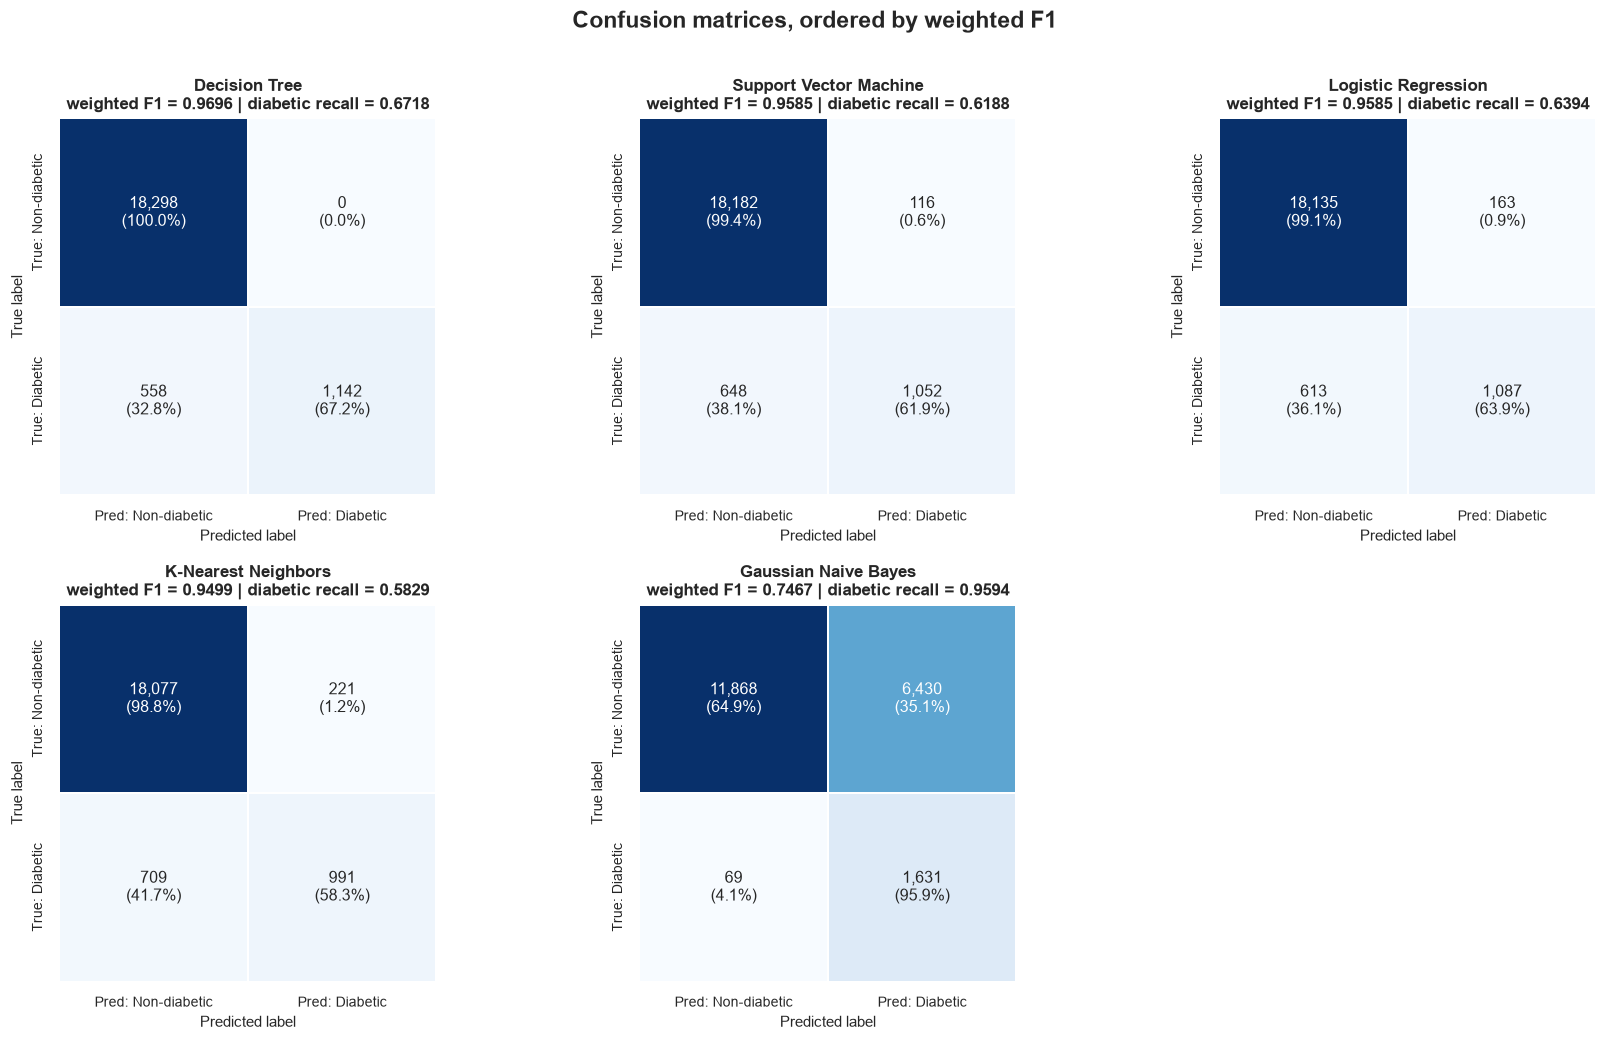

In [37]:
ordered = comparison["Model"].tolist()   # best first
ncols = 3
nrows = int(np.ceil(len(conf_mats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.4 * ncols, 4.7 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, ordered):
    cm = conf_mats[name]
    # row-normalise so each cell shows its share of the true class
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array([[f"{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)"
                        for j in range(cm.shape[1])] for i in range(cm.shape[0])])

    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                square=True, linewidths=1.2, linecolor="white",
                annot_kws={"fontsize": 10.5}, ax=ax,
                xticklabels=["Pred: Non-diabetic", "Pred: Diabetic"],
                yticklabels=["True: Non-diabetic", "True: Diabetic"])

    f1w = comparison.loc[comparison["Model"] == name, "F1 (weighted)"].iat[0]
    rec = comparison.loc[comparison["Model"] == name, "Recall (diabetic)"].iat[0]
    ax.set_title(f"{name}\nweighted F1 = {f1w:.4f} | diabetic recall = {rec:.4f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.tick_params(axis="both", labelsize=9)

for ax in axes[len(conf_mats):]:
    ax.set_visible(False)

fig.suptitle("Confusion matrices, ordered by weighted F1",
             fontsize=15, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

In [38]:
# false negatives are the clinically costly error: a missed diagnosis
err = []
for name in ordered:
    tn, fp, fn, tp = conf_mats[name].ravel()
    err.append({
        "Model": name, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Missed diabetics (FN)": fn, "False alarms (FP)": fp,
        "FN rate %": round(fn / (fn + tp) * 100, 2),
        "FP rate %": round(fp / (fp + tn) * 100, 2),
    })

print(f"Error breakdown on {int(y_test.sum()):,} true diabetics "
      f"and {int((1 - y_test).sum()):,} non-diabetics:\n")
print(pd.DataFrame(err).to_string(index=False))

print(f"\n\nPer-class report for {comparison.loc[0, 'Model']}:\n")
print(classification_report(y_test, preds[comparison.loc[0, "Model"]],
                            target_names=["Non-diabetic (0)", "Diabetic (1)"], digits=4))

Error breakdown on 1,700 true diabetics and 18,298 non-diabetics:

                 Model    TN   FP  FN   TP  Missed diabetics (FN)  False alarms (FP)  FN rate %  FP rate %
         Decision Tree 18298    0 558 1142                    558                  0      32.82       0.00
Support Vector Machine 18182  116 648 1052                    648                116      38.12       0.63
   Logistic Regression 18135  163 613 1087                    613                163      36.06       0.89
   K-Nearest Neighbors 18077  221 709  991                    709                221      41.71       1.21
  Gaussian Naive Bayes 11868 6430  69 1631                     69               6430       4.06      35.14


Per-class report for Decision Tree:

                  precision    recall  f1-score   support

Non-diabetic (0)     0.9704    1.0000    0.9850     18298
    Diabetic (1)     1.0000    0.6718    0.8037      1700

        accuracy                         0.9721     19998
       macro avg  

### Observation — 5

- Ranking by weighted F1: Decision Tree 0.9696, SVM 0.9585, Logistic Regression 0.9585, KNN 0.9499, Gaussian NB 0.7467.
- The Decision Tree records precision of exactly 1.0000 on the diabetic class, with 0 false positives across 18,298 non-diabetic test records.
- Gaussian NB scores 0.6750 accuracy, below the 91.5% majority-class baseline, while recording the highest diabetic recall at 0.9594.
- False negative rates: Decision Tree 32.8%, Logistic Regression 36.1%, SVM 38.1%, KNN 41.7%, Gaussian NB 4.1%.
- False positive rates: Decision Tree 0.0%, SVM 0.6%, Logistic Regression 0.9%, KNN 1.2%, Gaussian NB 35.1%.
- Four of the five models miss between 32% and 42% of diabetic patients; Gaussian NB shows the opposite pattern.

## 5.4 ROC curves and AUC

**ROC-AUC is a mandatory metric for this track.** It is also the most informative
single number under heavy imbalance, because it is computed from the **ranking** of
the predicted scores across every possible threshold rather than from the hard
predictions at the default 0.5 cut-off. A model can therefore have poor accuracy
and still have a strong AUC, which means its scores are ordered well and only the
threshold is wrong.

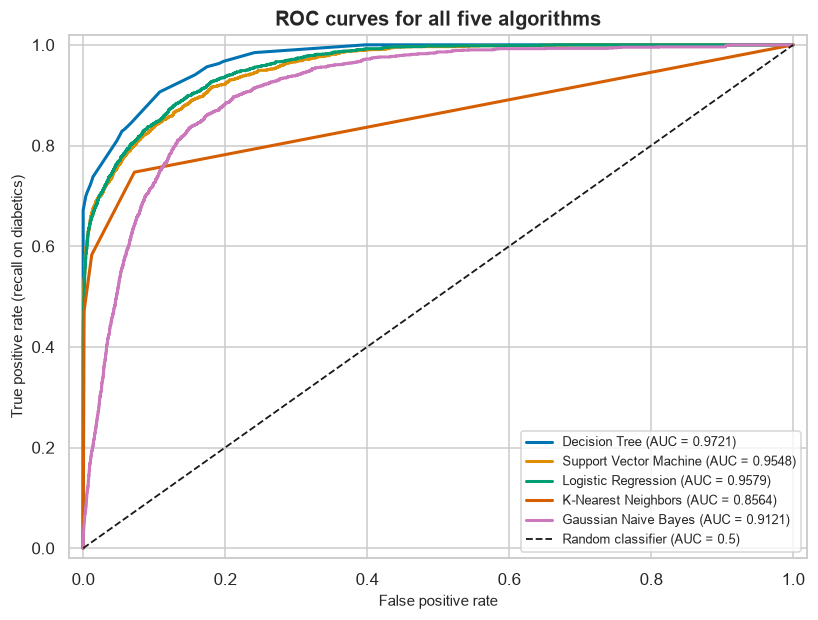

ROC-AUC, ranked:
                 Model  ROC-AUC  F1 (weighted)  Recall (diabetic)
         Decision Tree   0.9721         0.9696             0.6718
   Logistic Regression   0.9579         0.9585             0.6394
Support Vector Machine   0.9548         0.9585             0.6188
  Gaussian Naive Bayes   0.9121         0.7467             0.9594
   K-Nearest Neighbors   0.8564         0.9499             0.5829


In [39]:
fig, ax = plt.subplots(figsize=(7.6, 5.8))

for colour, name in zip(sns.color_palette(PALETTE, len(ordered)), ordered):
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    auc_val = comparison.loc[comparison["Model"] == name, "ROC-AUC"].iat[0]
    ax.plot(fpr, tpr, linewidth=2, color=colour, label=f"{name} (AUC = {auc_val:.4f})")

# the diagonal is what random guessing would produce
ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random classifier (AUC = 0.5)")
ax.set_title("ROC curves for all five algorithms", fontsize=13, fontweight="bold")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (recall on diabetics)")
ax.legend(fontsize=8.5, loc="lower right")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

print("ROC-AUC, ranked:")
print(comparison[["Model", "ROC-AUC", "F1 (weighted)", "Recall (diabetic)"]]
      .sort_values("ROC-AUC", ascending=False).round(4).to_string(index=False))

### Observation — 5.4

- ROC-AUC: Decision Tree 0.9721, Logistic Regression 0.9579, SVM 0.9548, Gaussian NB 0.9121, KNN 0.8564.
- Gaussian NB and KNN occupy different positions in this ranking than in the weighted F1 ranking.
- KNN with `k=3` and uniform weights can only return four distinct probability values: 0, 1/3, 2/3 and 1.

## 5.5 Cross-validation of the two best models

The guidelines require cross-validation for **at least the two best-performing
models**. Both are re-evaluated with 5-fold stratified cross-validation **on the
training split only**, which estimates how stable the result is across different
partitions rather than trusting a single split.

In [40]:
from sklearn.model_selection import cross_val_score

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
top2 = comparison["Model"].head(2).tolist()
print("Two best by weighted F1:", ", ".join(top2), "\n")

cv_rows = []
for name in top2:
    model = models[name]
    # models tuned on a subsample are cross-validated on a comparable subsample
    if name in ("K-Nearest Neighbors", "Support Vector Machine"):
        n_cv = KNN_FIT_N if name == "K-Nearest Neighbors" else SVC_FIT_N
        X_cv, y_cv = subsample(X_train_proc, y_train, n_cv)
        note = f"subsample, n={len(X_cv):,}"
    else:
        X_cv, y_cv = X_train_proc, y_train
        note = f"full training split, n={len(X_cv):,}"

    est = type(model)(**model.get_params())
    row = {"Model": name, "CV data": note}
    for label, scoring in [("F1 (weighted)", "f1_weighted"),
                           ("F1 (diabetic)", "f1"), ("ROC-AUC", "roc_auc")]:
        sc = cross_val_score(est, X_cv, y_cv, cv=cv5, scoring=scoring, n_jobs=-1)
        row[f"{label} mean"] = sc.mean()
        row[f"{label} std"] = sc.std()
        row[f"{label} folds"] = np.round(sc, 4)
    cv_rows.append(row)
    print(f"cross-validated  {name}  ({note})")

print("\n" + "=" * 96)
print("5-FOLD STRATIFIED CROSS-VALIDATION".center(96))
print("=" * 96)
for r in cv_rows:
    print(f"\n{r['Model']}   [{r['CV data']}]")
    for label in ["F1 (weighted)", "F1 (diabetic)", "ROC-AUC"]:
        print(f"  {label:<16} {r[f'{label} mean']:.4f} +/- {r[f'{label} std']:.4f}"
              f"   folds: {r[f'{label} folds']}")

# does the cross-validated estimate agree with the single held-out score?
print("\n" + "=" * 96)
print("Cross-validated (train) vs single held-out test score".center(96))
print("=" * 96)
cmp_rows = []
for r in cv_rows:
    held = comparison.loc[comparison["Model"] == r["Model"]]
    cmp_rows.append({
        "Model": r["Model"],
        "CV F1 (weighted)": round(r["F1 (weighted) mean"], 4),
        "CV std": round(r["F1 (weighted) std"], 4),
        "Test F1 (wtd)": round(held["F1 (weighted)"].iat[0], 4),
        "Difference": round(held["F1 (weighted)"].iat[0] - r["F1 (weighted) mean"], 4),
    })
print(pd.DataFrame(cmp_rows).to_string(index=False))

Two best by weighted F1: Decision Tree, Support Vector Machine 



cross-validated  Decision Tree  (full training split, n=79,988)


cross-validated  Support Vector Machine  (subsample, n=20,000)

                               5-FOLD STRATIFIED CROSS-VALIDATION                               

Decision Tree   [full training split, n=79,988]
  F1 (weighted)    0.9692 +/- 0.0009   folds: [0.9688 0.9686 0.9685 0.9709 0.9693]
  F1 (diabetic)    0.8013 +/- 0.0062   folds: [0.7981 0.797  0.7959 0.8127 0.803 ]
  ROC-AUC          0.9738 +/- 0.0013   folds: [0.9734 0.9753 0.9715 0.9749 0.974 ]

Support Vector Machine   [subsample, n=20,000]
  F1 (weighted)    0.9575 +/- 0.0031   folds: [0.9558 0.9612 0.9592 0.9589 0.9524]
  F1 (diabetic)    0.7270 +/- 0.0201   folds: [0.7165 0.7504 0.7406 0.734  0.6935]
  ROC-AUC          0.9569 +/- 0.0045   folds: [0.9521 0.9619 0.9621 0.9567 0.9517]

                     Cross-validated (train) vs single held-out test score                      
                 Model  CV F1 (weighted)  CV std  Test F1 (wtd)  Difference
         Decision Tree            0.9692  0.0009         0.9696      0

### Observation — 5.5

- Decision Tree: cross-validated weighted F1 0.9692 +/- 0.0009, against a test score of 0.9696.
- SVM: cross-validated weighted F1 0.9575 +/- 0.0031, against a test score of 0.9585.
- Fold-to-fold standard deviations are below 0.004 for both models.
- The cross-validated means differ from the held-out test scores by less than 0.002 in both cases.

## 5.6 Why did the Decision Tree get perfect precision?

A precision of exactly 1.0000, with zero false positives across 18,298 non-diabetic
records, should not be accepted at face value. In practice a number like that is
far more often a symptom of leakage, or of an artificial labelling rule, than
evidence of an unusually good model.

The pipeline itself is clean: section 3.7 proves the scaler never saw test data. So
if the cause is not leakage from the pipeline, it must be something about the data.
This cell interrogates the **raw, untouched** file directly.

In [41]:
raw = df_raw   # the original file, before dedup, cleaning or feature engineering

# if a simple threshold on one column perfectly predicts the label, the tree is
# not learning clinical signal - it is finding a rule someone built in
checks = []
for thr in [140, 160, 200, 220]:
    sub = raw[raw["blood_glucose_level"] > thr]
    checks.append({"rule": f"blood_glucose_level > {thr}", "n_records": len(sub),
                   "diabetes_rate_%": round(sub[TARGET].mean() * 100, 2) if len(sub) else np.nan})
for thr in [6.0, 6.5, 6.6]:
    sub = raw[raw["hbA1c_level"] > thr]
    checks.append({"rule": f"hbA1c_level > {thr}", "n_records": len(sub),
                   "diabetes_rate_%": round(sub[TARGET].mean() * 100, 2) if len(sub) else np.nan})

neither = raw[(raw["hbA1c_level"] <= 6.5) & (raw["blood_glucose_level"] <= 200)]
checks.append({"rule": "hbA1c <= 6.5 AND glucose <= 200", "n_records": len(neither),
               "diabetes_rate_%": round(neither[TARGET].mean() * 100, 2)})

print(f"Diabetes rate under simple threshold rules on the RAW data")
print(f"(population baseline = {raw[TARGET].mean() * 100:.2f}%)\n")
print(pd.DataFrame(checks).to_string(index=False))

print("\n--- Hard boundaries in the label ---")
print(f"Max glucose among NON-diabetics : {raw.loc[raw[TARGET] == 0, 'blood_glucose_level'].max()}")
print(f"Min glucose among diabetics     : {raw.loc[raw[TARGET] == 1, 'blood_glucose_level'].min()}")
print(f"Max hbA1c among NON-diabetics   : {raw.loc[raw[TARGET] == 0, 'hbA1c_level'].max()}")
print(f"Min hbA1c among diabetics       : {raw.loc[raw[TARGET] == 1, 'hbA1c_level'].min()}")

print("\n--- Signs of synthetic construction ---")
print(f"Distinct hbA1c values           : {raw['hbA1c_level'].nunique()}")
print(f"Distinct glucose values         : {raw['blood_glucose_level'].nunique()}")
mode_bmi = raw["bmi"].mode().iat[0]
print(f"Most common single bmi value    : {mode_bmi} "
      f"({(raw['bmi'] == mode_bmi).sum():,} records, {(raw['bmi'] == mode_bmi).mean() * 100:.1f}%)")

Diabetes rate under simple threshold rules on the RAW data
(population baseline = 8.50%)

                           rule  n_records  diabetes_rate_%
      blood_glucose_level > 140      48628            13.46
      blood_glucose_level > 160      10877            36.08
      blood_glucose_level > 200       3277           100.00
      blood_glucose_level > 220       2674           100.00
              hbA1c_level > 6.0      37114            17.49
              hbA1c_level > 6.5      12435            36.82
              hbA1c_level > 6.6       3895           100.00
hbA1c <= 6.5 AND glucose <= 200      86042             2.79

--- Hard boundaries in the label ---
Max glucose among NON-diabetics : 200
Min glucose among diabetics     : 126
Max hbA1c among NON-diabetics   : 6.6
Min hbA1c among diabetics       : 5.7

--- Signs of synthetic construction ---
Distinct hbA1c values           : 18
Distinct glucose values         : 18
Most common single bmi value    : 27.32 (25,495 records, 25.5%)


### Observation — 5.6

- All 3,277 records with `blood_glucose_level` above 200 are diabetic.
- All 3,895 records with `hbA1c_level` above 6.6 are diabetic.
- The maximum glucose among non-diabetics is exactly 200, and the maximum HbA1c among non-diabetics is exactly 6.6.
- The rate climbs gradually below those points: glucose above 140 gives 13.46% and above 160 gives 36.08%, before jumping to 100%.
- Below both thresholds there are 86,042 records, of which 2.79% are still diabetic.
- Each glycaemic marker takes only 18 distinct values, and 25,495 records share a BMI of exactly 27.32.

---
# 6. Conclusion

## 6.1 What was done

| Stage | Summary |
|-------|---------|
| Audit | 100,000 x 16, no nulls, 14 duplicates, class imbalance 10.76 to 1 |
| EDA | Distributions, correlation heatmap, class balance, two feature-target scatters, each with a written observation |
| Cleaning | Duplicates removed, IQR outliers winsorised using train-derived bounds |
| Encoding | One-hot for low-cardinality nominals, frequency encoding for `location` |
| Engineering | `bmi_category`, `age_risk_interaction`, `metabolic_risk_score`, all validated against the target |
| Split | 80/20, `stratify=y`, `random_state=42` |
| Scaling | `StandardScaler` fitted on `X_train` only, verified by assertion |
| Models | Logistic Regression, KNN, Gaussian NB, Decision Tree, SVC |
| Evaluation | Accuracy, weighted precision/recall/F1, ROC-AUC, confusion matrices, one ranked table |
| Validation | 5-fold stratified cross-validation on the two best models |

## 6.2 What the results show

1. **`hbA1c_level` and `blood_glucose_level` carry almost all the predictive
   signal.** Three independent lines of evidence agree: the correlation ranking in
   2.2, the odds ratios in 4.1, and the decision tree's root split plus 87% of its
   total impurity reduction in 4.4.

2. **The engineered features earned their place.** Prevalence rises monotonically
   across both `bmi_category` and `metabolic_risk_score`, and
   `age_risk_interaction` correlates with the target at +0.4106, higher than either
   of the two columns it is built from.

3. **Algorithm choice matters less than the class imbalance does.** The four
   discriminative models span just 0.0197 in weighted F1, while each carries a gap
   of roughly 0.30 to 0.37 between its weighted F1 and its recall on the diabetic
   class. Changing algorithm buys around two points; changing how the minority class
   is handled is worth an order of magnitude more.

4. **The headline score is partly an artefact of the data.** Section 5.6 shows the
   labels are rule-assigned above a glucose of 200 and an HbA1c of 6.6, which is
   what produces the Decision Tree's perfect precision.

## 6.3 Limitations

- **The dataset is substantially synthetic.** No non-diabetic record anywhere in
  100,000 rows exceeds a glucose of 200 or an HbA1c of 6.6. Real clinical data has
  no such clean boundary, so 0.97 weighted F1 should be read as a property of this
  dataset rather than an estimate of clinical performance.
- **KNN and SVC were tuned and fitted on stratified subsamples** for tractability,
  so their scores are conservative lower bounds and the comparison with the other
  three is not strictly like-for-like.
- **No decision-threshold tuning.** Every model uses the default 0.5 cut-off. Since
  false negatives dominate, lowering it would trade precision for recall and would
  very likely produce a better screening model.
- **No class-imbalance correction** was applied: no `class_weight="balanced"`, no
  resampling. Imbalance was handled through stratification and metric choice only.
- **Logistic Regression and Naive Bayes were not tuned.** Naive Bayes has no
  hyperparameter worth searching, but Logistic Regression could have been, and that
  was a scope decision rather than a principled one.
- **Target leakage is intrinsic to the problem.** HbA1c and glucose are the criteria
  by which diabetes is *diagnosed*, so the model reproduces a diagnostic rule rather
  than predicting future risk. This is separate from the train/test leakage that
  section 3.7 rules out: the pipeline is clean, but the features encode the answer.

## 6.4 Next steps

1. **Tune the decision threshold** against a stated cost ratio between a missed
   diagnosis and a false alarm, chosen on a validation split rather than the test set.
2. **Apply `class_weight="balanced"`** to Logistic Regression, the Decision Tree and SVC.
3. **Train the Part B ensembles** — Random Forest, AdaBoost, Gradient Boosting,
   Bagging and MLP — which the single tree's performance points toward.
4. **Re-run KNN and SVC on the full training split** to quantify what the
   subsampling cost them.
5. **Build a leakage-free early-warning variant** excluding both glycaemic markers,
   which removes the intrinsic leakage and the synthetic rule together. Expect much
   worse metrics, and a far more honest model.

In [42]:
print("=" * 70)
print("CLASSIFICATION TRACK - PART A SUMMARY")
print("=" * 70)
print(f"Dataset          : {df_raw.shape[0]:,} records, {df_raw.shape[1]} columns")
print(f"Target           : {TARGET} (0 = non-diabetic, 1 = diabetic)")
print(f"Class balance    : {(1-df_raw[TARGET].mean())*100:.1f}% / {df_raw[TARGET].mean()*100:.1f}%"
      f"  ({imbalance_ratio:.2f} : 1)")
print(f"Split            : {len(X_train_proc):,} train / {len(X_test_proc):,} test, "
      f"stratified, random_state={RANDOM_STATE}")
print(f"Features         : {X.shape[1]} before encoding, {X_train_proc.shape[1]} after")
print(f"Algorithms       : {len(models)} (Part A)")
print()
best = comparison.loc[0]
print(f"Best by F1       : {best['Model']}")
for m in ["Accuracy", "F1 (weighted)", "ROC-AUC", "Recall (diabetic)"]:
    print(f"    {m:<20} {best[m]:.4f}")
print(f"\nBaseline accuracy: {(1 - y_test.mean()):.4f} (always predict non-diabetic)")
print("=" * 70)
print("\nStill to do for Review 2: Random Forest, AdaBoost, Gradient Boosting,")
print("Bagging and MLP, then the consolidated 10-algorithm comparison table.")

CLASSIFICATION TRACK - PART A SUMMARY
Dataset          : 100,000 records, 16 columns
Target           : diabetes (0 = non-diabetic, 1 = diabetic)
Class balance    : 91.5% / 8.5%  (10.76 : 1)
Split            : 79,988 train / 19,998 test, stratified, random_state=42
Features         : 13 before encoding, 24 after
Algorithms       : 5 (Part A)

Best by F1       : Decision Tree
    Accuracy             0.9721
    F1 (weighted)        0.9696
    ROC-AUC              0.9721
    Recall (diabetic)    0.6718

Baseline accuracy: 0.9150 (always predict non-diabetic)

Still to do for Review 2: Random Forest, AdaBoost, Gradient Boosting,
Bagging and MLP, then the consolidated 10-algorithm comparison table.
